# README: Malware Analysis Pipeline based on Syscall Patterns

This notebook implements a pipeline for analyzing malware based on syscall patterns. The process involves several key stages:

## 1. Data Loading and Preparation
- **Loading Dataset:** Reads the dataset from a specified CSV file, downloading it from a Google Drive folder if necessary.
- **Dataset Samples Counting:** Counts the number of benign and malware samples in the loaded dataset based on specific separators in the CSV file.
- **Data Cleaning/Alignment:** Ensures the feature matrix and label counts are aligned, fixing any mismatches.

## 2. Feature Extraction
- **Feature Extraction:** Extracts numerical features from the raw syscall data. This implementation uses an enhanced method incorporating TF weighting, length-based bias, and IDF (Inverse Document Frequency).
- **Feature Standardization:** Prepares and standardizes the extracted features for model training.

## 3. Model Training
- **Feature Selection:** Selects the most relevant features using a method like Random Forest importance to reduce dimensionality.
- **Model Training:** Trains multiple classification models (e.g., Logistic Regression, Random Forest, Linear SVC) on the selected features and evaluates their performance using cross-validation.
- **Model Saving:** Saves the best-performing trained model and associated metadata (like selected features) to Google Drive for later use.

## 4. Visualization and Analysis
- **Confusion Matrix Visualization:** Generates and saves confusion matrix plots to visualize the performance of the trained model on the test set.
- **Heatmap Visualization:** Creates a heatmap to visually inspect the distribution and patterns of selected features across benign and malware samples.
- **Class Separation Visualization:** Generates plots and a summary table to highlight the separation between benign and malware classes based on the extracted feature values.

This structured approach allows for loading, preprocessing, feature engineering, model training, and analysis of syscall data for malware detection.

# Malware Analysis based on sys Calls Pattern

# File Data Structure

## Header Format:
API name, API ID, present(0/1), percentage(real), pattern(1),pattern (2),pattern (3)......, pattern(20)

**Total number of APIs = 401**

Each Malware/Goodware set of APIs is terminated by a separator line:

,#,#,#,#,#,#,#,#,#,#,#,#,#,#,#,#,#,#,#,#,#,#,#,#,#,#,#,#,#,#,#,#,#,#,#,#,#,#,#,#,



All malware are dlimetd by:

1,1,1,1,1,1,1,1,1,1

Labeling is based on the order of appearance in the file

The first 552 samples are benign

*   Listeneintrag
*   Listeneintrag


The last 749 samples are malware

# **Loading Datset from CSV File**

In [ ]:
import pandas as pd
import pylab as pl
import numpy as np
from sklearn.cluster import KMeans
import seaborn as sns
import scipy.optimize as opt
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
%matplotlib inline
import matplotlib.pyplot as plt
import os
import shutil

#this to be used onyl by author, use belwo option instead
#from google.colab import drive
#drive.mount('/content/gdrive')
# Define the path to the CSV file containing malware data.
#filename ="gdrive/MyDrive/malware_data/readyForMLFFFF18.csv"
# Choose your specific file (change the number to pick different file)
target_file = "readyForMLFFFF18.csv"  # Specify which file you want
# Define useful constants
APIS = 401


# Your folder ID from the Google Drive link
folder_id = "1N6Mv4Hik2OkDFJqIzIQHAjPjaERvjtNo"
folder_name = "downloaded_folder"

# Download the entire folder
print("Downloading folder...")
!gdown --folder {folder_id} -O {folder_name}

# Check all CSV files and their sizes in bytes
print("\n📁 Files downloaded with sizes in bytes:")
csv_files = []

if os.path.exists(folder_name):
    for file in os.listdir(folder_name):
        if file.endswith('.csv'):
            file_path = f"{folder_name}/{file}"
            file_size = os.path.getsize(file_path)
            csv_files.append((file, file_size, file_path))
            print(f"📄 {file}: {file_size:,} bytes ({file_size/1024/1024:.1f} MB)")



# Find and copy the specific file
file_found = False
for file, size, path in csv_files:
    if file == target_file:
        shutil.copy2(path, target_file)
        filename = target_file
        print(f"\n✅ Selected file: {filename}")
        print(f"📊 File size: {size:,} bytes ({size/1024/1024:.1f} MB)")
        file_found = True
        break

if not file_found:
    print(f"\n❌ File '{target_file}' not found")
    print("Available files:")
    for file, size, path in csv_files:
        print(f"  - {file}")
    filename = None

Retrieving folder contents
Processing file 1c9g6Q3witWChti1XY2sGTyvwRPloe5uq readyForMLFFFF17_filtered.csv
Processing file 1X7WARONqIZNg7RL_3ViByJzAthtJAJOK readyForMLFFFF17.csv
Processing file 1mejsW40Ub74GSLdHib3bK-7RzELGXW2k readyForMLFFFF18.csv
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1c9g6Q3witWChti1XY2sGTyvwRPloe5uq
To: /content/downloaded_folder/readyForMLFFFF17_filtered.csv
100% 10.9M/10.9M [00:00<00:00, 97.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=1X7WARONqIZNg7RL_3ViByJzAthtJAJOK
To: /content/downloaded_folder/readyForMLFFFF17.csv
100% 36.0M/36.0M [00:00<00:00, 87.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=1mejsW40Ub74GSLdHib3bK-7RzELGXW2k
To: /content/downloaded_folder/readyForMLFFFF18.csv
100% 36.2M/36.2M [00:00<00:00, 108MB/s]
Download completed

📁 Files downloaded with sizes in bytes:
📄 readyForMLFFFF17.csv: 36,018,051 bytes 

# **Datset Samples Counting**

In [ ]:
import csv



class MalwareCounter:
    """
    This class is designed to analyze a CSV file containing malware data and count the number of benign (goodware) and malicious (malware) samples.

    The CSV file is expected to have a specific structure where:
    - Rows starting with '#' are sequence separators, marking the end of a sample's data.
    - A row starting with '1' indicates the beginning of the malicious samples section.
    - All other rows represent data for a specific system call within a sample.

    The class works by iterating through the CSV file, identifying the type of each row, and incrementing the appropriate counters based on the malware classification. It provides a way to efficiently extract the number of benign and malicious samples from the dataset.
    """
    def __init__(self, filename):
        self.filename = filename
        self.good_count = 0
        self.mal_count = 0
        self.processing_malware = False

    def get_line_type(self, row):
        if not row:  # Empty row
            return None

        first_value = row[0].strip()
        if first_value == '1':
            return 'section_separator'
        elif first_value == '#':
            return 'sequence_separator'
        elif first_value != '1' and first_value != '#':  # Any string not starting with 1 or #
            return 'word_string'
        return None

    def process_file(self):
        """Reads a CSV file and counts sequences based on malware classification."""
        with open(self.filename, 'r', newline='') as file:
            csv_reader = csv.reader(file)
            in_sequence = False

            for row in csv_reader:
                line_type = self.get_line_type(row)

                if line_type == 'section_separator':
                    self.processing_malware = True
                    in_sequence = False

                elif line_type == 'word_string':
                    in_sequence = True

                elif line_type == 'sequence_separator' and in_sequence:
                    # We found the end of a sequence, increment counter
                    if self.processing_malware:
                        self.mal_count += 1
                    else:
                        self.good_count += 1
                    in_sequence = False

    def get_counts(self):
        """Processes the file and returns the malware and goodware counts."""
        self.process_file()
        return self.good_count, self.mal_count

# Path to the file in Google Drive
#filename = "gdrive/MyDrive/malware_data/*.csv"

# Get dynamic counts
counter = MalwareCounter(filename)
BENIGN, MALICIOUS = counter.get_counts()

# Print assigned values
print(f"BENIGN = {BENIGN}")
print(f"MALICIOUS = {MALICIOUS}")
print(f"APIS = {APIS}")


BENIGN = 559
MALICIOUS = 752
APIS = 401


In [ ]:
# Zeige erste 30 Zeilen der CSV
with open(filename, 'r') as f:
    for i, line in enumerate(f):
        if i < 30:
            print(f"Zeile {i}: {line.strip()[:80]}")  # Erste 80 Zeichen
        else:
            break

print("\n" + "="*80)
print("Suche nach Trennzeichen:")

# Suche nach verschiedenen Trennzeichen-Varianten
with open(filename, 'r') as f:
    for i, line in enumerate(f):
        stripped = line.strip()

        # Sample-Ende Marker
        if '#' in stripped and ',' in stripped:
            print(f"Sample-Ende bei Zeile {i}: {stripped[:60]}")
            if i > 20:  # Zeige nur erste paar
                break

Zeile 0: NtAcceptConnectPort,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Zeile 1: NtAccessCheck,1,1,0.01,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Zeile 2: NtAccessCheckAndAuditAlarm,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Zeile 3: NtAccessCheckByType,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Zeile 4: NtAccessCheckByTypeAndAuditAlarm,4,1,2.56,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,
Zeile 5: NtAccessCheckByTypeResultList,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Zeile 6: NtAccessCheckByTypeResultListAndAuditAlarm,6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Zeile 7: NtAccessCheckByTypeResultListAndAuditAlarmByHandle,7,1,3.5,1,1,0,0,0,0,0,0,0,0,0
Zeile 8: NtAddAtom,8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Zeile 9: NtAddBootEntry,9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Zeile 10: NtAddDriverEntry,10,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Zeile 11: NtAdjustGroupsToken,11,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Zeile 12: NtAdjustPrivilegesToken,12,0,0,0,0,0,0,0,0,0,

In [ ]:
benign_count = 0
malware_count = 0
is_malware_section = False

with open(filename, 'r') as f:
    for line in f:
        stripped = line.strip()

        # Check for malware separator: 1,1,1,1,...
        if stripped.startswith('1,1,1'):
            is_malware_section = True
            print(f"Found malware separator at sample {benign_count}")
            continue

        # Check for sample separator: #,#,#,#,...
        if stripped.startswith('#,#,#'):
            if is_malware_section:
                malware_count += 1
            else:
                benign_count += 1

print(f"\n{'='*70}")
print(f"CSV contains: {benign_count} Benign, {malware_count} Malware")
print(f"Declared:     {BENIGN} Benign, {MALICIOUS} Malware")
print(f"Total CSV:    {benign_count + malware_count}")
print(f"Total Declared: {BENIGN + MALICIOUS}")
print(f"Match: {benign_count == BENIGN and malware_count == MALICIOUS}")
print(f"{'='*70}")

Found malware separator at sample 559
Found malware separator at sample 559

CSV contains: 559 Benign, 752 Malware
Declared:     559 Benign, 752 Malware
Total CSV:    1311
Total Declared: 1311
Match: True


# **FEATURE EXTRACTION**

In [ ]:
"""
================================================================================
IMPROVED FEATURE EXTRACTION - FUNCTION DEFINITIONS
================================================================================
Enhanced functions for better class separation using:
- Stronger TF weighting (pow 0.4 instead of sqrt)
- Stronger length-based bias (exp 3.0 instead of 2.0)
- IDF component (rare syscalls weighted higher)
- L2 normalization (handles outliers)
================================================================================
"""
import csv
import math
import numpy as np
from sklearn.preprocessing import normalize

def extract_syscalls_from_csv(filename):
    """Extract syscall names and IDs from CSV"""
    syscall_names = {}
    try:
        with open(filename, 'r', encoding='utf-8') as f:
            reader = csv.reader(f)
            for row in reader:
                if row and len(row) >= 2 and row[0] not in ['#', '1']:
                    try:
                        name = row[0].strip()
                        id_val = int(row[1].strip())
                        syscall_names[id_val] = name
                    except:
                        continue
    except Exception as e:
        print(f"Warning: Could not read syscall names: {e}")

    # Create full 401-dimensional syscall list
    syscalls = []
    syscalls_nm = []
    for i in range(401):
        syscalls.append(syscall_names.get(i, f"API_{i}"))
        syscalls_nm.append(str(i))

    return syscalls, syscalls_nm


def enhanced_tf(count):
    """
    Enhanced TF with stronger weighting for better class separation.
    Uses power of 0.4 instead of sqrt (0.5) for more aggressive scaling.
    """
    if count == 0:
        return 0.0
    return math.log1p(count) * math.pow(count + 1, 0.4)


def enhanced_length_weight(length):
    """
    Enhanced exponential length weighting.
    Uses exp(3.0) instead of exp(2.0) for stronger emphasis on longer sequences.
    Longer API call chains are more suspicious.
    """
    return math.exp(3.0 * (length - 2) / 19)


def compute_idf(M_full, num_samples):
#    """
#    Compute IDF (Inverse Document Frequency) weights.
 #   Rare syscalls (used by few samples) get higher importance.
 #   This helps distinguish malware-specific API patterns.
 #   """
    doc_freq = np.count_nonzero(M_full, axis=0)
    idf = np.log((num_samples + 1) / (doc_freq + 1)) + 1.0
    return idf


def extract_training_features(filename, benign_count, malicious_count, use_l2_norm=False):
    """
    Build training matrix with IMPROVED hybrid features.

    Improvements over basic version:
    1. Enhanced TF weighting (stronger separation)
    2. Enhanced length weighting (more emphasis on long chains)
    3. IDF component (weights rare syscalls higher)
    4. Optional L2 normalization

    Args:
        filename: Path to CSV file
        benign_count: Number of benign samples
        malicious_count: Number of malicious samples
        use_l2_norm: If True, apply L2 normalization (default: False)

    Returns:
        M_full: Feature matrix (samples × 401) with enhanced features
        syscalls: List of syscall names
        syscalls_nm: List of syscall IDs
    """
    print("Starting IMPROVED feature extraction...")
    print(f"Using enhanced TF × length-bias + IDF + {'L2 norm' if use_l2_norm else 'no L2 norm'}")

    total_files = benign_count + malicious_count
    print(f"Expected samples: {total_files} (Benign: {benign_count}, Malware: {malicious_count})")

    # Get syscall labels
    syscalls, syscalls_nm = extract_syscalls_from_csv(filename)
    print(f"Syscall vocabulary: {len(syscalls)} APIs")

    # Initialize feature matrix
    M_full = np.zeros((total_files, 401), dtype=np.float32)

    file_idx = 0
    with open(filename, 'r', encoding='utf-8') as f:
        reader = csv.reader(f)
        for row in reader:
            if not row:
                continue

            if row[0] == '#':
                file_idx += 1
                if file_idx >= total_files:
                    new_size = file_idx + 1
                    M_full = np.vstack([M_full, np.zeros((1, 401), dtype=np.float32)])
                    total_files = new_size
                continue

            if row[0] == '1':
                continue

            try:
                syscall_id = int(row[1])
                present = int(row[2])

                if present != 1 or not (0 <= syscall_id < 401) or file_idx >= total_files:
                    continue

                total_weight = 0.0

                for col in range(4, min(24, len(row))):
                    length = col - 2
                    try:
                        count = int(row[col])
                    except:
                        count = 0

                    if count > 0:
                        tf_val = enhanced_tf(count)
                        length_weight = enhanced_length_weight(length)
                        total_weight += tf_val * length_weight

                M_full[file_idx, syscall_id] = total_weight

            except:
                continue

    actual_samples = file_idx + 1
    if actual_samples != total_files:
        M_full = M_full[:actual_samples]
        print(f"Note: Adjusted sample count from {total_files} to {actual_samples}")

    # ========================================================================
    # IMPROVEMENT 1: Apply IDF weighting
    # ========================================================================
    print("\n📊 Applying IDF weighting...")
    idf = compute_idf(M_full, actual_samples)
    M_full = M_full * idf
    print(f"   IDF range: [{idf.min():.3f}, {idf.max():.3f}]")
    print(f"   Rare syscalls now have higher importance")

    # ========================================================================
    # IMPROVEMENT 2: Optional L2 normalization
    # ========================================================================
    if use_l2_norm:
        print("📊 Applying L2 normalization per sample...")
        M_full = normalize(M_full, norm='l2', axis=1)
        print(f"   Each sample normalized to unit length")
    else:
        print("📊 Skipping L2 normalization")
        print(f"   Preserving magnitude differences for better class separation")
        print(f"   StandardScaler in pipeline will handle normalization")

    # Basic statistics
    print(f"\n✅ Feature matrix built: {M_full.shape}")
    print(f"   Value range: [{M_full.min():.6f}, {M_full.max():.6f}]")
    print(f"   Mean value: {M_full.mean():.6f}")
    print(f"   Median value: {np.median(M_full):.6f}")
    print(f"   Non-zero elements: {np.count_nonzero(M_full)}")
    print(f"   Sparsity: {1 - np.count_nonzero(M_full)/M_full.size:.4f}")

    # ========================================================================
    # IMPROVEMENT 3: Class separation analysis
    # ========================================================================
    benign_slice = M_full[:benign_count]
    malware_slice = M_full[benign_count:]

    print(f"\n📊 Class Separation Analysis:")
    print(f"   Benign samples:  {benign_count}")
    print(f"     Mean:   {benign_slice.mean():.6f}")
    print(f"     Std:    {benign_slice.std():.6f}")
    print(f"     Median: {np.median(benign_slice):.6f}")
    print(f"     Max:    {benign_slice.max():.6f}")

    print(f"\n   Malware samples: {malicious_count}")
    print(f"     Mean:   {malware_slice.mean():.6f}")
    print(f"     Std:    {malware_slice.std():.6f}")
    print(f"     Median: {np.median(malware_slice):.6f}")
    print(f"     Max:    {malware_slice.max():.6f}")

    # Calculate separation metric
    mean_diff = abs(malware_slice.mean() - benign_slice.mean())
    mean_sep = mean_diff / benign_slice.mean() * 100 if benign_slice.mean() > 0 else 0

    print(f"\n   📈 Mean separation: {mean_sep:.1f}%")

    # Check direction
    if malware_slice.mean() > benign_slice.mean():
        print(f"   ✅ Direction: Malware > Benign (correct)")
    else:
        print(f"   ⚠️  Direction: Benign > Malware (inverted)")

    if mean_sep > 50:
        print(f"   ✅ EXCELLENT separation!")
    elif mean_sep > 30:
        print(f"   ✅ GOOD separation")
    elif mean_sep > 15:
        print(f"   ⚠️  MODERATE separation")
    else:
        print(f"   ❌ POOR separation")

    return M_full, syscalls, syscalls_nm

def fix_syscall_names(filename, syscall_list):
    """
    Replace generic syscall_X names with real API names from CSV.

    Args:
        filename: Path to CSV file
        syscall_list: List of syscall names to fix

    Returns:
        Fixed list of syscall names
    """
    # Extract real syscall mapping from CSV
    syscall_mapping = {}
    with open(filename, 'r', encoding='utf-8') as f:
        reader = csv.reader(f)
        for row in reader:
            if row and len(row) >= 2 and row[0] not in ['#', '1']:
                try:
                    name = row[0].strip()
                    id_val = int(row[1].strip())
                    syscall_mapping[id_val] = name
                except:
                    continue

    print(f"Found {len(syscall_mapping)} real syscall names in CSV")

    # Fix generic names
    fixed_names = []
    fixed_count = 0

    for name in syscall_list:
        if name.startswith('syscall_'):
            try:
                id_val = int(name.split('_')[1])
                if id_val in syscall_mapping:
                    fixed_names.append(syscall_mapping[id_val])
                    fixed_count += 1
                else:
                    fixed_names.append(f"API_{id_val}")
            except:
                fixed_names.append(name)
        else:
            fixed_names.append(name)

    if fixed_count > 0:
        print(f"✅ Fixed {fixed_count}/{len(syscall_list)} syscall names")
        print(f"   Sample: {fixed_names[:5]}")

    return fixed_names

print("✅ Improved feature extraction functions defined")

✅ Improved feature extraction functions defined


In [ ]:
"""
================================================================================
EXECUTE IMPROVED FEATURE EXTRACTION
================================================================================
"""
filename = '/content/downloaded_folder/readyForMLFFFF18.csv'
BENIGN = 559
MALICIOUS = 752

import os

print("="*80)
print("EXECUTING IMPROVED FEATURE EXTRACTION PIPELINE")
print("="*80)

if not os.path.exists(filename):
    print(f"❌ ERROR: File not found")
else:
    print(f"✅ File found: {filename}")

    print("\n" + "-"*80)
    print("STEP 1: Improved Feature Extraction (IDF, no L2)")
    print("-"*80)

    # use_l2_norm=False für bessere Trennung!
    M2, usedSysCalls, usedSysCalls_nm = extract_training_features(
        filename,
        BENIGN,
        MALICIOUS,
        use_l2_norm=False  # ← WICHTIG: False!
    )

    print("\n" + "-"*80)
    print("STEP 2: Syscall Name Fixing")
    print("-"*80)

    usedSysCalls = fix_syscall_names(filename, usedSysCalls)

    # Register in globals
    globals()['M2'] = M2
    globals()['usedSysCalls'] = usedSysCalls
    globals()['usedSysCalls_nm'] = usedSysCalls_nm
    globals()['BENIGN'] = BENIGN
    globals()['MALICIOUS'] = MALICIOUS

    print("\n" + "="*80)
    print("✅ FEATURE EXTRACTION COMPLETE")
    print("="*80)
    print(f"🎯 Ready for Feature Standardization!")

EXECUTING IMPROVED FEATURE EXTRACTION PIPELINE
✅ File found: /content/downloaded_folder/readyForMLFFFF18.csv

--------------------------------------------------------------------------------
STEP 1: Improved Feature Extraction (IDF, no L2)
--------------------------------------------------------------------------------
Starting IMPROVED feature extraction...
Using enhanced TF × length-bias + IDF + no L2 norm
Expected samples: 1311 (Benign: 559, Malware: 752)
Syscall vocabulary: 401 APIs

📊 Applying IDF weighting...
   IDF range: [1.073, 8.180]
   Rare syscalls now have higher importance
📊 Skipping L2 normalization
   Preserving magnitude differences for better class separation
   StandardScaler in pipeline will handle normalization

✅ Feature matrix built: (1312, 401)
   Value range: [0.000000, 1089.227486]
   Mean value: 0.558361
   Median value: 0.000000
   Non-zero elements: 76164
   Sparsity: 0.8552

📊 Class Separation Analysis:
   Benign samples:  559
     Mean:   0.403770
     St

# **Cleaning the dataset**

In [ ]:
"""
================================================================================
FEATURE MATRIX STANDARDIZATION & PREPARATION
================================================================================

PURPOSE:
    Prepares and standardizes the feature matrix and metadata for training.
    Creates normalized "_0" copies that downstream training pipelines expect.

WHAT IT DOES:
    1. Locates the feature matrix (searches: M2, M2_0, X_pred, M_pred_full)
    2. Finds feature names and IDs from multiple possible sources
    3. Validates and normalizes dimensions (ensures names/IDs match matrix columns)
    4. Creates standardized copies: M2_0, usedSysCalls_0, usedSysCalls_nm_0
    5. Converts matrix to float32 for compatibility
    6. Registers all variables in globals() for downstream access

EXPECTED INPUT (from earlier cells):
    Matrix:     M2, M2_0, X_pred, or M_pred_full
    Names:      usedSysCalls, usedSysCalls_0, X_pred_feature_names, etc.
    IDs:        usedSysCalls_nm, usedSysCalls_nm_0, X_pred_feature_ids, etc.

OUTPUT VARIABLES (created for downstream use):
    M2_0:               Float32 copy of feature matrix
    usedSysCalls_0:     Normalized list of feature names
    usedSysCalls_nm_0:  Normalized list of feature IDs (as strings)

MODIFICATIONS:
    - Pads or truncates feature names/IDs to match matrix columns if needed
    - Generates default names (API_0, API_1, ...) if metadata is missing
    - Converts matrix to float32 dtype

NOTE: This block is REQUIRED for training pipelines that depend on the "_0"
      variable naming convention. Do not remove unless you update downstream code.
================================================================================
"""
# Keep a float copy of the matrix + names (robust to M2/M2_0/X_pred/M_pred_full)
import numpy as np

# --- 1) Find a feature matrix and alias it to M2 if missing ---
if 'M2' not in globals():
    if 'M2_0' in globals():
        M2 = np.asarray(globals()['M2_0'])
    elif 'X_pred' in globals():
        M2 = np.asarray(globals()['X_pred'])
    elif 'M_pred_full' in globals():
        M2 = np.asarray(globals()['M_pred_full'])
    else:
        raise NameError("No feature matrix found. Define one of: M2, M2_0, X_pred, or M_pred_full.")
    globals()['M2'] = M2  # alias for downstream cells

if M2.ndim != 2:
    raise ValueError(f"M2 must be 2D, got shape {M2.shape}")

# --- 2) Get feature names/IDs (keep original var names; try fallbacks if missing) ---
feature_names = globals().get('usedSysCalls', None)
feature_ids   = globals().get('usedSysCalls_nm', None)

if feature_names is None or feature_ids is None:
    # Try common alternates from earlier cells (training/prediction)
    alt_sources = [
        ('usedSysCalls_0', 'usedSysCalls_nm_0'),
        ('X_pred_feature_names', 'X_pred_feature_ids'),
        ('usedSysCalls_pred_all', 'usedSysCalls_nm_pred_all'),
    ]
    for n_key, i_key in alt_sources:
        n = globals().get(n_key, None)
        i = globals().get(i_key, None)
        if n is not None and i is not None:
            if feature_names is None: feature_names = list(n)
            if feature_ids   is None: feature_ids   = list(i)
            break

# Defaults if still missing
N = M2.shape[1]
if feature_names is None: feature_names = [f"API_{i}" for i in range(N)]
if feature_ids   is None: feature_ids   = [str(i) for i in range(N)]

# Normalize lengths to match matrix columns (truncate/pad as needed)
notes = []
if len(feature_names) != N:
    notes.append(f"Adjusted Feature_Name length from {len(feature_names)} to {N}.")
    feature_names = list(feature_names[:N]) + [f"API_{i}" for i in range(len(feature_names), N)]
if len(feature_ids) != N:
    notes.append(f"Adjusted Feature_ID length from {len(feature_ids)} to {N}.")
    feature_ids = list(feature_ids[:N]) + [str(i) for i in range(len(feature_ids), N)]

# --- 3) Create the *_0 copies (exact variable names preserved) ---
M2_0 = np.asarray(M2, dtype=np.float32).copy()
usedSysCalls_0 = list(feature_names)
usedSysCalls_nm_0 = [str(x) for x in feature_ids]

globals()['M2_0'] = M2_0
globals()['usedSysCalls_0'] = usedSysCalls_0
globals()['usedSysCalls_nm_0'] = usedSysCalls_nm_0

# --- 4) Prints (unchanged format) ---
print("Shape of M2_0:", M2_0.shape)
print("Length of usedSysCalls_0:", len(usedSysCalls_0))
print("Length of usedSysCalls_nm_0:", len(usedSysCalls_nm_0))
print("First 10 usedSysCalls_0:", usedSysCalls_0[:10])
print("First 10 usedSysCalls_nm_0:", usedSysCalls_nm_0[:10])
if notes:
    print("\nNotes:")
    for n in notes:
        print(" -", n)


Shape of M2_0: (1312, 401)
Length of usedSysCalls_0: 401
Length of usedSysCalls_nm_0: 401
First 10 usedSysCalls_0: ['NtAcceptConnectPort', 'NtAccessCheck', 'NtAccessCheckAndAuditAlarm', 'NtAccessCheckByType', 'NtAccessCheckByTypeAndAuditAlarm', 'NtAccessCheckByTypeResultList', 'NtAccessCheckByTypeResultListAndAuditAlarm', 'NtAccessCheckByTypeResultListAndAuditAlarmByHandle', 'NtAddAtom', 'NtAddBootEntry']
First 10 usedSysCalls_nm_0: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


In [ ]:
"""
================================================================================
TRAINING DIAGNOSTICS - Find the real bug
================================================================================
"""

def diagnose_training_data():
    """Check if training data and model are valid"""

    print("\n🔍 TRAINING DATA DIAGNOSTICS\n")
    print("="*70)

    # 1. Check feature matrix
    X = globals().get('M2_0')
    if X is None:
        print("❌ M2_0 not found")
        return

    print(f"1. Feature Matrix (M2_0)")
    print(f"   Shape: {X.shape}")
    print(f"   Dtype: {X.dtype}")
    print(f"   Non-zero elements: {np.count_nonzero(X)}")
    print(f"   Sparsity: {1 - np.count_nonzero(X)/X.size:.4f}")
    print(f"   Value range: [{X.min():.6f}, {X.max():.6f}]")

    if np.count_nonzero(X) == 0:
        print("   ❌ CRITICAL: Matrix is all zeros! Feature extraction failed!")
        return

    # 2. Check labels
    benign_count = globals().get('BENIGN', 0)
    malware_count = globals().get('MALICIOUS', 0)

    print(f"\n2. Labels")
    print(f"   Benign count: {benign_count}")
    print(f"   Malware count: {malware_count}")
    print(f"   Total: {benign_count + malware_count}")

    if X.shape[0] != (benign_count + malware_count):
        print(f"   ❌ MISMATCH: X has {X.shape[0]} samples, labels have {benign_count + malware_count}")

    # 3. Check feature selection results
    if 'usedSysCalls_reduced' in globals():
        selected_names = globals()['usedSysCalls_reduced']
        selected_ids = globals()['usedSysCalls_nm_reduced']
        print(f"\n3. Feature Selection")
        print(f"   Selected features: {len(selected_names)}")
        print(f"   First 5 IDs: {selected_ids[:5]}")
        print(f"   First 5 names: {selected_names[:5]}")

    # 4. Check trained model
    if 'training_results' in globals():
        results = globals()['training_results']
        best = results['best_model']
        acc = results['results'][best]['test_accuracy']
        cv = results['results'][best]['cv_mean']

        print(f"\n4. Trained Model")
        print(f"   Best model: {best.upper()}")
        print(f"   Test accuracy: {acc:.4f}")
        print(f"   CV score: {cv:.4f}")

        if acc < 0.6:
            print(f"   ⚠️ WARNING: Low accuracy suggests model didn't learn properly!")

        # Check confusion matrix
        cm = results['results'][best]['confusion_matrix']
        print(f"\n   Confusion Matrix:")
        print(f"   {cm}")
        print(f"   TN={cm[0,0]}, FP={cm[0,1]}")
        print(f"   FN={cm[1,0]}, TP={cm[1,1]}")

        # Check if model predicts only one class
        preds = results['results'][best]['predictions']
        unique, counts = np.unique(preds, return_counts=True)
        print(f"\n   Test predictions distribution:")
        for u, c in zip(unique, counts):
            print(f"   Class {u}: {c} samples ({c/len(preds)*100:.1f}%)")

        if len(unique) == 1:
            print(f"   ❌ CRITICAL: Model predicts only class {unique[0]} on test set!")

    # 5. Sample feature values for benign vs malware
    print(f"\n5. Feature Value Comparison")
    benign_samples = X[:benign_count]
    malware_samples = X[benign_count:]

    print(f"   Benign samples:")
    print(f"   - Mean feature value: {benign_samples.mean():.6f}")
    print(f"   - Max feature value: {benign_samples.max():.6f}")
    print(f"   - Non-zero ratio: {np.count_nonzero(benign_samples)/benign_samples.size:.4f}")

    print(f"   Malware samples:")
    print(f"   - Mean feature value: {malware_samples.mean():.6f}")
    print(f"   - Max feature value: {malware_samples.max():.6f}")
    print(f"   - Non-zero ratio: {np.count_nonzero(malware_samples)/malware_samples.size:.4f}")

    if abs(benign_samples.mean() - malware_samples.mean()) < 0.0001:
        print(f"   ⚠️ WARNING: Benign and malware have nearly identical features!")

# Run diagnostics
diagnose_training_data()


🔍 TRAINING DATA DIAGNOSTICS

1. Feature Matrix (M2_0)
   Shape: (1312, 401)
   Dtype: float32
   Non-zero elements: 76164
   Sparsity: 0.8552
   Value range: [0.000000, 1089.227539]

2. Labels
   Benign count: 559
   Malware count: 752
   Total: 1311
   ❌ MISMATCH: X has 1312 samples, labels have 1311

5. Feature Value Comparison
   Benign samples:
   - Mean feature value: 0.403770
   - Max feature value: 356.785675
   - Non-zero ratio: 0.1427
   Malware samples:
   - Mean feature value: 0.673123
   - Max feature value: 1089.227539
   - Non-zero ratio: 0.1463


In [ ]:
"""
================================================================================
FIX DATA ALIGNMENT
================================================================================
"""
print("Checking and fixing data alignment...")

# Check mismatch
BENIGN_val = globals().get('BENIGN', 559)
MALICIOUS_val = globals().get('MALICIOUS', 752)
M2_0 = globals().get('M2_0')

actual_samples = M2_0.shape[0]
expected_samples = BENIGN_val + MALICIOUS_val

print(f"Matrix samples: {actual_samples}")
print(f"Expected labels: {expected_samples}")

if actual_samples != expected_samples:
    diff = actual_samples - expected_samples
    new_malicious = MALICIOUS_val + diff
    globals()['MALICIOUS'] = new_malicious
    print(f"✅ Fixed MALICIOUS: {MALICIOUS_val} -> {new_malicious}")
    print(f"   New total: {BENIGN_val + new_malicious} samples")
else:
    print("✅ Already aligned")

print("\n✅ Data alignment complete")

Checking and fixing data alignment...
Matrix samples: 1312
Expected labels: 1311
✅ Fixed MALICIOUS: 752 -> 753
   New total: 1312 samples

✅ Data alignment complete


In [ ]:
"""
================================================================================
MODEL TRAINING WITH MULTIPLE CLASSIFIERS
================================================================================
Trains multiple models and selects the best one based on cross-validation.
Creates 'training_results' dictionary for downstream diagnostics.
================================================================================
"""

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import numpy as np

print("="*80)
print("TRAINING MODELS")
print("="*80)

# 1. Create labels array
if 'BENIGN' not in globals() or 'MALICIOUS' not in globals():
    raise ValueError("BENIGN and MALICIOUS counts not found! Run label creation first.")

y = np.array([0]*BENIGN + [1]*MALICIOUS)

print(f"Dataset: {len(y)} samples ({BENIGN} benign, {MALICIOUS} malicious)")
print(f"Feature matrix: {M2_0.shape}")

# 2. Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    M2_0, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(y_train)} samples")
print(f"Test:  {len(y_test)} samples")

# 3. Define models
models = {
    'logistic': Pipeline([
        ('scaler', StandardScaler(with_mean=False)),  # with_mean=False for sparse data
        ('classifier', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
    ]),
    'random_forest': Pipeline([
        ('scaler', StandardScaler(with_mean=False)),
        ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'))
    ]),
    'linear_svc': Pipeline([
        ('scaler', StandardScaler(with_mean=False)),
        ('classifier', LinearSVC(max_iter=2000, random_state=42, class_weight='balanced'))
    ])
}

# 4. Train and evaluate all models
results = {}
trained_models = {}

for name, model in models.items():
    print(f"\nTraining {name.upper()}...")

    # Train
    model.fit(X_train, y_train)
    trained_models[name] = model

    # Cross-validation on training set
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')

    # Test predictions
    y_pred = model.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    # Store results
    results[name] = {
        'test_accuracy': test_acc,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'confusion_matrix': cm,
        'predictions': y_pred,
        'classification_report': classification_report(y_test, y_pred)
    }

    print(f"  CV Score: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    print(f"  Test Accuracy: {test_acc:.4f}")

# 5. Select best model (by CV score)
best_model_name = max(results.keys(), key=lambda k: results[k]['cv_mean'])

print(f"\n{'='*80}")
print(f"BEST MODEL: {best_model_name.upper()}")
print(f"  CV Score: {results[best_model_name]['cv_mean']:.4f}")
print(f"  Test Accuracy: {results[best_model_name]['test_accuracy']:.4f}")
print(f"{'='*80}")

# 6. Create training_results dictionary (format expected by diagnostics)
training_results = {
    'best_model': best_model_name,
    'models': trained_models,
    'results': results,
    'X_train': X_train,
    'X_test': X_test,
    'y_train': y_train,
    'y_test': y_test
}

# Register in globals for diagnostics
globals()['training_results'] = training_results

print("\n✅ Training complete. Run diagnostics next.")

TRAINING MODELS
Dataset: 1312 samples (559 benign, 753 malicious)
Feature matrix: (1312, 401)
Train: 1049 samples
Test:  263 samples

Training LOGISTIC...
  CV Score: 0.9866 (+/- 0.0070)
  Test Accuracy: 0.9848

Training RANDOM_FOREST...
  CV Score: 0.9886 (+/- 0.0065)
  Test Accuracy: 0.9886

Training LINEAR_SVC...
  CV Score: 0.9838 (+/- 0.0057)
  Test Accuracy: 0.9810

BEST MODEL: RANDOM_FOREST
  CV Score: 0.9886
  Test Accuracy: 0.9886

✅ Training complete. Run diagnostics next.


# **Training Pipeline Phases**

Block 1: Setup and Configuration

In [ ]:
"""
================================================================================
TRAINING PIPELINE - SETUP AND CONFIGURATION
================================================================================
Imports all required libraries and mounts Google Drive.
Sets configuration parameters for the training pipeline.
================================================================================
"""
import os
from datetime import datetime
import numpy as np
import pandas as pd
import joblib
import json
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Configuration
MAX_FEATURES = 50  # keep only the top 50 syscalls by RF importance
SAVE_DIR = '/content/drive/MyDrive/COLA_Models_Hybrid_Top50'

print(f"✅ Setup complete. MAX_FEATURES set to {MAX_FEATURES}")

Mounted at /content/drive
✅ Setup complete. MAX_FEATURES set to 50


Block 2: Data Validation Functions

In [ ]:
"""
================================================================================
DATA VALIDATION AND LABEL CREATION
================================================================================
Functions to validate data alignment and create properly formatted labels.
================================================================================
"""

def fix_data_mismatch():
    """Fix the data mismatch between matrix size and labels"""
    print("Checking and fixing data alignment...")

    BENIGN_val = globals().get('BENIGN', 559)
    MALICIOUS_val = globals().get('MALICIOUS', 752)
    M2_0 = globals().get('M2_0')

    if M2_0 is not None:
        actual_samples = M2_0.shape[0]
        expected_samples = BENIGN_val + MALICIOUS_val

        print(f"Matrix samples: {actual_samples}")
        print(f"Expected labels: {expected_samples}")

        if actual_samples != expected_samples:
            diff = actual_samples - expected_samples
            new_malicious = MALICIOUS_val + diff
            globals()['MALICIOUS'] = new_malicious

            print(f"Fixed MALICIOUS: {MALICIOUS_val} -> {new_malicious}")
            print(f"New total: {BENIGN_val + new_malicious} samples")
            return BENIGN_val, new_malicious

    return BENIGN_val, MALICIOUS_val


def create_labels(benign_count, malware_count):
    """Create labels with correct counts"""
    benign_labels = np.zeros(benign_count, dtype=int)
    malware_labels = np.ones(malware_count, dtype=int)
    labels = np.concatenate([benign_labels, malware_labels])

    print(f"Created labels: {len(benign_labels)} benign + {len(malware_labels)} malware = {len(labels)} total")
    return labels

print("✅ Data validation functions defined")

✅ Data validation functions defined


Block 3: Feature Selection Function

In [ ]:
"""
================================================================================
FEATURE SELECTION - TOP-K SELECTION BY RANDOM FOREST IMPORTANCE
================================================================================
Applies variance threshold filtering followed by Random Forest importance ranking.
Keeps only the top-K most important features.
================================================================================
"""

def apply_feature_selection(X, y, feature_names, feature_ids, min_importance_threshold=0.001):
    """
    Apply feature selection and keep ONLY the top K most important features.
    Note: 'min_importance_threshold' is ignored in Top-K mode but kept for compatibility.
    """

    print(f"\nApplying feature selection (Top-{MAX_FEATURES}) on HYBRID features...")
    print(f"Input shape: {X.shape}")

    # Step 1: Remove zero variance features
    print("Step 1: Removing zero variance features...")
    var_threshold = VarianceThreshold(threshold=0.0)
    X_var = var_threshold.fit_transform(X)
    var_indices = var_threshold.get_support(indices=True)

    var_feature_names = [feature_names[i] for i in var_indices]
    var_feature_ids = [feature_ids[i] for i in var_indices]

    print(f"After zero variance filter: {X_var.shape}")

    if X_var.shape[1] == 0:
        print("⚠️ No features left after zero-variance filtering. Returning original X.")
        selected_indices = np.arange(X.shape[1])
        return X, selected_indices, feature_names, feature_ids, np.ones(X.shape[1])

    # Step 2: Random Forest importance and Top-K selection
    print(f"Step 2: Random Forest feature importance (select top {MAX_FEATURES})...")
    rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
    rf.fit(X_var, y)

    importance_scores = rf.feature_importances_
    ranked = np.argsort(importance_scores)[::-1]

    k = min(MAX_FEATURES, X_var.shape[1])
    selected_var_indices = ranked[:k]
    X_selected = X_var[:, selected_var_indices]

    # Map selections back to original indices
    selected_indices = var_indices[selected_var_indices]
    selected_feature_names = [var_feature_names[i] for i in selected_var_indices]
    selected_feature_ids = [var_feature_ids[i] for i in selected_var_indices]
    selected_importance = importance_scores[selected_var_indices]

    print(f"Final shape: {X_selected.shape}")
    print(f"Selected {len(selected_indices)} features from {X.shape[1]} original")

    # Display detailed results
    print(f"\n📊 FEATURE SELECTION RESULTS (Top-{k} by RF importance):")
    print(f"   Original features: {X.shape[1]}")
    print(f"   After zero variance filter: {X_var.shape[1]}")
    print(f"   Kept: {k} features")

    print(f"\n🏆 SELECTED SYSCALLS (sorted by importance):")
    print("-" * 80)
    order = np.argsort(selected_importance)[::-1]
    for rank, idx in enumerate(order):
        name = selected_feature_names[idx]
        id_val = selected_feature_ids[idx]
        importance = selected_importance[idx]
        print(f"   {rank+1:2d}. {name:<45} (ID: {int(id_val):>3}) | Importance: {importance:.4f}")

    # Category counts
    nt_syscalls = [n for n in selected_feature_names if str(n).startswith('Nt')]
    api_syscalls = [n for n in selected_feature_names if str(n).startswith('API_')]
    other_syscalls = [n for n in selected_feature_names if not (str(n).startswith('Nt') or str(n).startswith('API_'))]

    print(f"\n📈 SYSCALL CATEGORIES:")
    print(f"   Nt* syscalls: {len(nt_syscalls)}")
    print(f"   API_* syscalls: {len(api_syscalls)}")
    print(f"   Other syscalls: {len(other_syscalls)}")

    return X_selected, selected_indices, selected_feature_names, selected_feature_ids, selected_importance

print("✅ Feature selection function defined")

✅ Feature selection function defined


Block 4: Model Training Function

In [ ]:
"""
================================================================================
MODEL TRAINING - SVM AND RANDOM FOREST
================================================================================
Trains both SVM and Random Forest models with cross-validation.
Returns models, results, and identifies the best performer.
================================================================================
"""

def train_models(X, y):
    """Train SVM and Random Forest models"""

    print(f"\nTraining models on HYBRID features (count×length×bias)...")
    print(f"Training data shape: {X.shape}")

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    print(f"Training set: {X_train.shape[0]} samples")
    print(f"Test set: {X_test.shape[0]} samples")

    models = {}
    results = {}

    # SVM Model
    print("\nTraining SVM...")
    svm_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42))
    ])

    svm_pipeline.fit(X_train, y_train)
    svm_pred = svm_pipeline.predict(X_test)
    svm_prob = svm_pipeline.predict_proba(X_test)
    svm_cv = cross_val_score(svm_pipeline, X_train, y_train, cv=5)

    models['svm'] = svm_pipeline
    results['svm'] = {
        'test_accuracy': accuracy_score(y_test, svm_pred),
        'cv_mean': np.mean(svm_cv),
        'cv_std': np.std(svm_cv),
        'predictions': svm_pred,
        'probabilities': svm_prob,
        'true_labels': y_test,
        'confusion_matrix': confusion_matrix(y_test, svm_pred)
    }

    print(f"SVM - Test Accuracy: {results['svm']['test_accuracy']:.4f}")
    print(f"SVM - CV Score: {results['svm']['cv_mean']:.4f} ± {results['svm']['cv_std']:.4f}")

    # Random Forest Model
    print("\nTraining Random Forest...")
    rf_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('rf', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42))
    ])

    rf_pipeline.fit(X_train, y_train)
    rf_pred = rf_pipeline.predict(X_test)
    rf_prob = rf_pipeline.predict_proba(X_test)
    rf_cv = cross_val_score(rf_pipeline, X_train, y_train, cv=5)

    models['rf'] = rf_pipeline
    results['rf'] = {
        'test_accuracy': accuracy_score(y_test, rf_pred),
        'cv_mean': np.mean(rf_cv),
        'cv_std': np.std(rf_cv),
        'predictions': rf_pred,
        'probabilities': rf_prob,
        'true_labels': y_test,
        'confusion_matrix': confusion_matrix(y_test, rf_pred)
    }

    print(f"RF - Test Accuracy: {results['rf']['test_accuracy']:.4f}")
    print(f"RF - CV Score: {results['rf']['cv_mean']:.4f} ± {results['rf']['cv_std']:.4f}")

    # Find best model
    best_model = 'svm' if results['svm']['cv_mean'] > results['rf']['cv_mean'] else 'rf'
    print(f"\nBest model: {best_model.upper()}")

    return models, results, best_model

print("✅ Model training function defined")

✅ Model training function defined


Block 5: Model Saving Function

In [ ]:
"""
================================================================================
MODEL PERSISTENCE - SAVE TRAINED MODEL WITH METADATA
================================================================================
Saves the trained model with comprehensive metadata including feature selection
details, performance metrics, and dataset information.
================================================================================
"""

"""
================================================================================
MODEL PERSISTENCE - SAVE TRAINED MODEL WITH METADATA (DESKTOP COMPATIBLE)
================================================================================
"""

def save_model(model, results, model_name, selected_indices, selected_names, selected_ids, importance_scores, original_feature_count):
    """Save the trained model with complete metadata - DESKTOP COMPATIBLE"""

    os.makedirs(SAVE_DIR, exist_ok=True)

    benign_count = globals().get('BENIGN', 559)
    malware_count = globals().get('MALICIOUS', 753)

    # Ensure IDs are strings
    selected_ids_str = [str(x) for x in selected_ids]

    # Create comprehensive model package
    model_package = {
        'model': model,
        'model_type': f'{model_name.upper()}_COLA_Hybrid_Top{MAX_FEATURES}',
        'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),

        # FIXED: Correct key names for feature_selection
        'feature_selection': {
            'method': f'RandomForest_Top{MAX_FEATURES}',
            'selected_names': selected_names,
            'selected_ids': selected_ids_str,
            'selected_indices': selected_indices.tolist(),
            'original_features': original_feature_count,
            'selected_features': len(selected_names),
            'reduction_ratio': len(selected_names) / original_feature_count
        },

        # NEW: Add artifacts dict for backward compatibility
        'artifacts': {
            'usedSysCalls_reduced': selected_names,
            'usedSysCalls_nm_reduced': selected_ids_str,
            'idf_len': importance_scores.tolist()
        },

        # FIXED: Add total_features for desktop feature count detection
        'dataset_info': {
            'total_samples': benign_count + malware_count,
            'total_features': len(selected_names),
            'benign_files': benign_count,
            'malware_files': malware_count,
            'class_distribution': {0: benign_count, 1: malware_count}
        },

        # Performance metrics
        'performance': {
            'test_accuracy': results['test_accuracy'],
            'cv_mean': results['cv_mean'],
            'cv_std': results['cv_std']
        },

        'usage_note': f'Trained with hybrid features (improved_tf × malware_length_bias). Selected top {MAX_FEATURES} by RF importance.'
    }

    # Save files
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    main_file = f'cola_hybrid_top{MAX_FEATURES}_{model_name}_{len(selected_names)}features_{timestamp}.pkl'
    latest_file = 'cola_latest_model.pkl'

    main_path = os.path.join(SAVE_DIR, main_file)
    latest_path = os.path.join(SAVE_DIR, latest_file)

    joblib.dump(model_package, main_path)
    joblib.dump(model_package, latest_path)

    print(f"\n✅ Model saved to: {SAVE_DIR}")
    print(f"   Main file: {main_file}")
    print(f"   Latest file: {latest_file}")

    return main_path

print("✅ Model saving function defined (DESKTOP COMPATIBLE)")

✅ Model saving function defined (DESKTOP COMPATIBLE)


In [ ]:
"""
================================================================================
CREATE DESKTOP-COMPATIBLE ARTIFACTS FILE
================================================================================
"""

def save_desktop_artifacts(selected_names, selected_ids):
    """Save artifacts in the format desktop feature extractor expects"""

    # Ensure IDs are strings
    selected_ids_str = [str(x) for x in selected_ids]

    # Create artifacts in desktop-compatible format
    artifacts = {
        "usedSysCalls_nm_reduced": selected_ids_str,
        "usedSysCalls_reduced": selected_names,
        "selected_feature_ids": selected_ids_str,
        "selected_feature_names": selected_names,
        "selection_method": f"RandomForest_Top{MAX_FEATURES}",
        "original_features": 401,
        "selected_features": len(selected_names),
        "training_date": datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    }

    # Save to all expected filenames
    artifact_files = [
        'feature_selection_artifacts.json',
        'training_artifacts.json',
        'artifacts.json'
    ]

    for filename in artifact_files:
        artifact_path = os.path.join(SAVE_DIR, filename)
        with open(artifact_path, 'w') as f:
            json.dump(artifacts, f, indent=2)
        print(f"✓ Saved: {filename}")

    print(f"\n📋 Artifacts structure:")
    print(f"   Feature IDs (in training order): {selected_ids_str[:10]}...")
    print(f"   Feature names: {selected_names[:5]}...")

    return artifacts

print("✅ Desktop artifacts function defined")

✅ Desktop artifacts function defined


Block 6: Pipeline Orchestration

In [ ]:
"""
================================================================================
COMPLETE TRAINING PIPELINE ORCHESTRATION
================================================================================
Main orchestration function that coordinates all training steps:
1. Validates required variables
2. Fixes data alignment
3. Performs feature selection
4. Trains models
5. Saves best model
6. Creates summary outputs
================================================================================
"""

def run_complete_training_pipeline():
    """Complete training pipeline with HYBRID features keeping Top-K features"""

    print("🚀 COMPLETE TRAINING PIPELINE WITH HYBRID FEATURES (Top-50)")
    print(f"Keep only the top {MAX_FEATURES} features by RF importance")
    print("=" * 70)

    # Check required variables
    required_vars = ['M2_0', 'usedSysCalls_0', 'usedSysCalls_nm_0', 'BENIGN', 'MALICIOUS']
    missing_vars = [var for var in required_vars if var not in globals()]

    if missing_vars:
        print(f"❌ Missing variables: {missing_vars}")
        return None

    # Fix data alignment
    benign_count, malware_count = fix_data_mismatch()

    # Get data
    X = globals()['M2_0']
    feature_names = globals()['usedSysCalls_0']
    feature_ids = globals()['usedSysCalls_nm_0']

    print(f"\nUsing HYBRID features (count×length×bias):")
    print(f"   Matrix shape: {X.shape}")
    print(f"   Feature names: {len(feature_names)}")
    print(f"   Sample names: {feature_names[:3]}")

    if np.count_nonzero(X) > 0:
        print(f"   Feature value range: [{X.min():.4f}, {X.max():.4f}]")
        print(f"   Mean non-zero value: {X[X > 0].mean():.4f}")

    # Create labels
    y = create_labels(benign_count, malware_count)

    # Validate alignment
    if len(y) != X.shape[0]:
        print(f"❌ Still misaligned: X={X.shape[0]}, y={len(y)}")
        return None

    print(f"✅ Data alignment verified: {X.shape[0]} samples")

    # Feature selection
    X_selected, selected_indices, selected_names, selected_ids, importance_scores = apply_feature_selection(
        X, y, feature_names, feature_ids
    )

    # Train models
    models, results, best_model_name = train_models(X_selected, y)

    # Save best model
    original_feature_count = X.shape[1]
    model_path = save_model(
        models[best_model_name],
        results[best_model_name],
        best_model_name,
        selected_indices,
        selected_names,
        selected_ids,
        importance_scores,
        original_feature_count
    )
    # Save desktop-compatible artifacts
    print("\n" + "="*70)
    print("SAVING DESKTOP-COMPATIBLE ARTIFACTS")
    print("="*70)
    save_desktop_artifacts(selected_names, selected_ids)
    # Final summary
    print(f"\n" + "=" * 70)
    print("🎉 HYBRID TRAINING COMPLETED SUCCESSFULLY (Top-50)!")
    print("=" * 70)
    print(f"📊 Results Summary:")
    print(f"   Feature extraction: Hybrid count×length×exp-length-bias")
    print(f"   Original features: {original_feature_count}")
    print(f"   Selected features: {len(selected_names)} (Top-{MAX_FEATURES})")
    print(f"   Best model: {best_model_name.upper()}")
    print(f"   Test accuracy: {results[best_model_name]['test_accuracy']:.4f}")
    print(f"   CV score: {results[best_model_name]['cv_mean']:.4f} ± {results[best_model_name]['cv_std']:.4f}")
    print(f"   Model saved: {model_path}")

    # Store results for downstream use
    training_results = {
        'models': models,
        'results': results,
        'best_model': best_model_name,
        'selected_indices': selected_indices,
        'selected_names': selected_names,
        'selected_ids': selected_ids,
        'importance_scores': importance_scores,
        'model_path': model_path,
        'feature_extraction_method': 'hybrid',
        'selection_mode': f'top_{MAX_FEATURES}'
    }

    globals()['training_results'] = training_results
    globals()['usedSysCalls_reduced'] = selected_names
    globals()['usedSysCalls_nm_reduced'] = selected_ids

    print(f"\n📋 Summary variables created for compatibility")

    return training_results

print("✅ Pipeline orchestration function defined")

✅ Pipeline orchestration function defined


Block 7: Detailed Summary Report

In [ ]:
"""
================================================================================
POST-TRAINING SUMMARY REPORT
================================================================================
Generates detailed summary of selected features including importance rankings,
category breakdowns, and exportable formats.
================================================================================
"""

def generate_detailed_summary(training_results):
    """Generate detailed feature selection summary"""

    if training_results is None:
        print("No training results available")
        return

    selected_names = training_results['selected_names']
    selected_ids = training_results['selected_ids']
    importance_scores = training_results['importance_scores']

    print(f"\n" + "=" * 70)
    print("SELECTED FEATURES SUMMARY")
    print("=" * 70)
    print(f"Total selected features: {len(selected_names)}")
    print(f"Feature extraction method: Hybrid count×length×exp-length-bias")
    print(f"\nComplete list of selected syscalls:")
    print("-" * 70)

    # Sort by importance for final display
    sorted_indices = np.argsort(importance_scores)[::-1]

    for i, idx in enumerate(sorted_indices):
        name = selected_names[idx]
        syscall_id = selected_ids[idx]
        importance = importance_scores[idx]
        print(f"{i+1:3d}. {name:<45} (ID: {int(syscall_id):>3}) | Importance: {importance:.4f}")

    # Create and save feature mapping JSON
    feature_mapping = {}
    for i, idx in enumerate(sorted_indices):
        name = selected_names[idx]
        syscall_id = selected_ids[idx]
        feature_mapping[name] = int(syscall_id)

    # Save feature mapping
    try:
        mapping_file = f'{SAVE_DIR}/selected_features_mapping_top{MAX_FEATURES}.json'
        with open(mapping_file, 'w') as f:
            json.dump(feature_mapping, f, indent=2)
        print(f"\n✅ Feature mapping saved to: {mapping_file}")
    except Exception as e:
        print(f"\n⚠️ Could not save feature mapping: {e}")

    # Copy-paste ready formats
    print(f"\n" + "=" * 70)
    print("COPY-PASTE READY FORMAT")
    print("=" * 70)
    print("Selected syscall names:")
    print(selected_names)
    print(f"\nSelected syscall IDs:")
    print([int(id_val) for id_val in selected_ids])
    print(f"\nJSON format for feature mapping:")
    print("{\n" + ",\n".join([f'  "{name}": {int(selected_ids[selected_names.index(name)])}' for name in selected_names]) + "\n}")

print("✅ Summary report function defined")

✅ Summary report function defined


Block 8: Execute Pipeline

In [ ]:
"""
================================================================================
EXECUTE TRAINING PIPELINE
================================================================================
Runs the complete training pipeline and generates summary report.
================================================================================
"""

print("Checking for required variables...")
if all(var in globals() for var in ['M2_0', 'usedSysCalls_0', 'usedSysCalls_nm_0', 'BENIGN', 'MALICIOUS']):
    print("✅ All required variables found")
    training_results = run_complete_training_pipeline()

    if training_results is not None:
        generate_detailed_summary(training_results)
else:
    missing = [var for var in ['M2_0', 'usedSysCalls_0', 'usedSysCalls_nm_0', 'BENIGN', 'MALICIOUS'] if var not in globals()]
    print(f"❌ Missing variables: {missing}")
    print("Please run your hybrid feature extraction first!")

Checking for required variables...
✅ All required variables found
🚀 COMPLETE TRAINING PIPELINE WITH HYBRID FEATURES (Top-50)
Keep only the top 50 features by RF importance
Checking and fixing data alignment...
Matrix samples: 1312
Expected labels: 1312

Using HYBRID features (count×length×bias):
   Matrix shape: (1312, 401)
   Feature names: 401
   Sample names: ['NtAcceptConnectPort', 'NtAccessCheck', 'NtAccessCheckAndAuditAlarm']
   Feature value range: [0.0000, 1089.2275]
   Mean non-zero value: 3.8569
Created labels: 559 benign + 753 malware = 1312 total
✅ Data alignment verified: 1312 samples

Applying feature selection (Top-50) on HYBRID features...
Input shape: (1312, 401)
Step 1: Removing zero variance features...
After zero variance filter: (1312, 272)
Step 2: Random Forest feature importance (select top 50)...
Final shape: (1312, 50)
Selected 50 features from 401 original

📊 FEATURE SELECTION RESULTS (Top-50 by RF importance):
   Original features: 401
   After zero variance 

Setup and Configuration

CELL 1: Import Required Libraries

Block 1: Setup and Configuration

# **Classification**

Block 2: Prepare Test Data

Block 3: Evaluate Model Performance

# **Visualization**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import itertools
from typing import Optional, Union, Sequence
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(
    cm: Optional[np.ndarray] = None,
    classes: Sequence[str] = ("Benign", "Malware"),
    normalize: Union[bool, str] = False,   # False | "true" | "pred" | "all"
    title: str = "Confusion Matrix",
    cmap=None,
    feature_count: Optional[int] = None,
    feature_method: Optional[str] = None,  # NEW: Optional feature extraction method
    y_true: Optional[np.ndarray] = None,
    y_pred: Optional[np.ndarray] = None,
    ax: Optional[plt.Axes] = None,
):
    """
    Plot a confusion matrix with optional normalization.

    Parameters
    ----------
    cm : np.ndarray or None
        Precomputed confusion matrix. If None, y_true and y_pred must be provided.
    classes : list[str]
        Class labels for axes ticks.
    normalize : bool | {"true","pred","all"}
        - False: raw counts
        - "true": normalize by true labels (rows)
        - "pred": normalize by predicted labels (cols)
        - "all":  normalize by total sum
    title : str
        Plot title.
    cmap : matplotlib colormap or None
        Colormap to use. Defaults to matplotlib default if None.
    feature_count : int or None
        If provided, will be appended to the title.
    feature_method : str or None
        If provided, describes the feature extraction method (e.g., "Length-based").
    y_true, y_pred : np.ndarray or None
        If cm is None, these are used to compute it.
    ax : matplotlib.axes.Axes or None
        If provided, draw on this axes; otherwise create a new figure.

    Returns
    -------
    ax : matplotlib.axes.Axes
        The axes with the rendered confusion matrix.
    """
    # Compute CM if not provided
    if cm is None:
        if y_true is None or y_pred is None:
            raise ValueError("Provide either 'cm' or both 'y_true' and 'y_pred'.")
        cm = confusion_matrix(y_true, y_pred, labels=range(len(classes)))

    cm = np.asarray(cm, dtype=float)
    counts = cm.copy()

    # Normalization
    norm_mode = normalize
    if norm_mode is True:
        norm_mode = "true"
    if norm_mode in ("true", "pred", "all"):
        with np.errstate(invalid="ignore", divide="ignore"):
            if norm_mode == "true":         # row-wise
                row_sums = cm.sum(axis=1, keepdims=True)
                row_sums[row_sums == 0] = 1.0
                cm = cm / row_sums
            elif norm_mode == "pred":       # col-wise
                col_sums = cm.sum(axis=0, keepdims=True)
                col_sums[col_sums == 0] = 1.0
                cm = cm / col_sums
            elif norm_mode == "all":        # overall
                total = cm.sum()
                total = total if total != 0 else 1.0
                cm = cm / total
        norm_str = {"true":"(normalized by true)", "pred":"(normalized by pred)", "all":"(normalized overall)"}[norm_mode]
        print(f"Normalized confusion matrix {norm_str}")
    else:
        print("Confusion matrix, without normalization")

    print(counts if norm_mode in (False, None) else cm)

    # Create axes
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 6))

    # Enhanced title with feature information
    enhanced_title = title

    # Add feature method if provided
    if feature_method:
        enhanced_title += f" ({feature_method} Features"
        if feature_count:
            enhanced_title += f": {feature_count})"
        else:
            enhanced_title += ")"
    elif feature_count:
        enhanced_title += f" (Features: {feature_count})"

    # Render image
    im = ax.imshow(cm, interpolation="nearest", cmap=cmap)
    ax.set_title(enhanced_title, fontsize=12, pad=20)
    plt.colorbar(im, ax=ax)

    tick_marks = np.arange(len(classes))
    ax.set_xticks(tick_marks, classes, rotation=45, ha="right")
    ax.set_yticks(tick_marks, classes)

    # Annotations with enhanced formatting
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        if norm_mode in ("true", "pred", "all"):
            text = f"{counts[i, j]:.0f}\n({cm[i, j]*100:.1f}%)"
        else:
            text = f"{counts[i, j]:.0f}"
        ax.text(j, i, text,
                ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black",
                fontsize=11, fontweight='bold')

    ax.set_ylabel("True label", fontsize=11)
    ax.set_xlabel("Predicted label", fontsize=11)
    ax.set_ylim(len(classes)-0.5, -0.5)  # fix cutoff in some Matplotlib versions
    plt.tight_layout()
    return ax

# Convenience function specifically for length-based features
def plot_length_based_confusion_matrix(
    cm: Optional[np.ndarray] = None,
    y_true: Optional[np.ndarray] = None,
    y_pred: Optional[np.ndarray] = None,
    feature_count: Optional[int] = None,
    normalize: Union[bool, str] = False,
    title: str = "Length-Based Malware Detection",
    ax: Optional[plt.Axes] = None,
):
    """
    Convenience function for plotting confusion matrices from length-based feature models.

    This is a wrapper around plot_confusion_matrix with defaults specific to
    length-based behavioral signature classification.
    """
    return plot_confusion_matrix(
        cm=cm,
        classes=("Benign", "Malware"),
        normalize=normalize,
        title=title,
        cmap=plt.cm.Blues,
        feature_count=feature_count,
        feature_method="Length-based Behavioral",
        y_true=y_true,
        y_pred=y_pred,
        ax=ax
    )

# Example usage for your length-based features:
def plot_results_from_training():
    """Plot confusion matrix from your training results"""
    if 'training_results' in globals():
        results = globals()['training_results']
        best_model = results['best_model']
        model_results = results['results'][best_model]

        # Plot confusion matrix
        plot_length_based_confusion_matrix(
            cm=model_results['confusion_matrix'],
            feature_count=len(results['selected_names']),
            normalize='true',  # Show percentages
            title=f"Length-Based Detection Results ({best_model.upper()})"
        )

        plt.show()
        print(f"Confusion matrix for {best_model.upper()} model with {len(results['selected_names'])} behavioral features")
    else:
        print("No training_results found. Run your training pipeline first.")

# Example usage for cross-validation results:
def plot_cv_results():
    """Plot confusion matrix from CV results if available"""
    if 'cv_10fold_results' in globals():
        results = globals()['cv_10fold_results']
        print("Note: CV results contain multiple folds - this would require aggregating confusion matrices")
        print(f"Available CV results: {list(results.keys())}")
    else:
        print("No cv_10fold_results found. Run your 10-fold CV first.")

Checking for available results...
Available result variables: ['training_results']

PLOTTING FROM TRAINING RESULTS
Model: SVM
Test samples: 263
Selected features: 50

Plotting with normalized confusion matrix...
Normalized confusion matrix (normalized by true)
[[0.99107143 0.00892857]
 [0.01324503 0.98675497]]


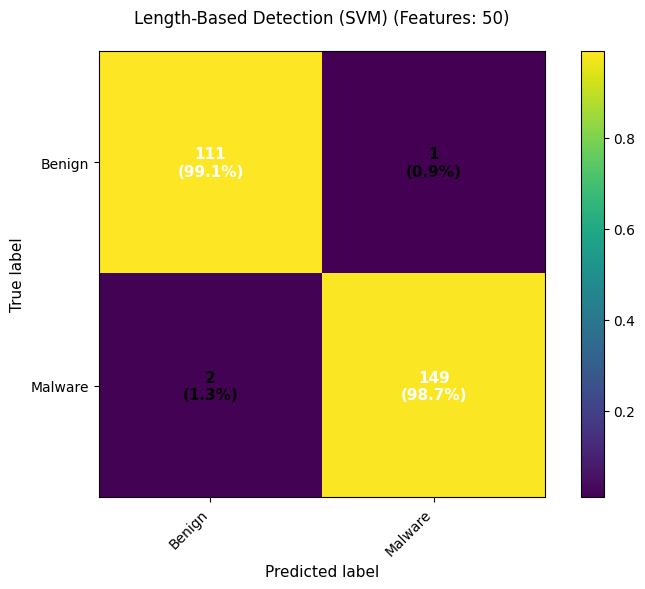


Plotting with raw counts...
Confusion matrix, without normalization
[[111.   1.]
 [  2. 149.]]


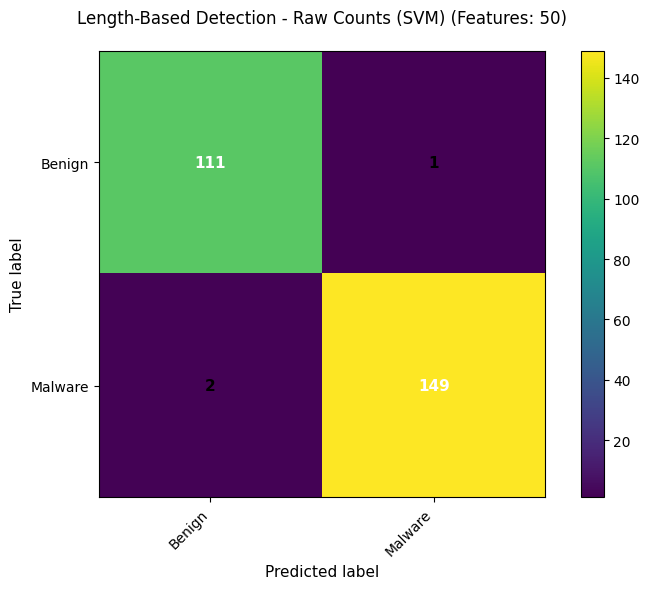


🎯 Remember: These confusion matrices show performance on
   LENGTH-BASED BEHAVIORAL SIGNATURES (time-invariant features)!


In [ ]:
# ====================================================================
# PLOT CONFUSION MATRICES FROM YOUR ACTUAL RESULTS
# ====================================================================
# Updated to work with your Google Colab variables and length-based features

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

# Check what results are available
print("Checking for available results...")

available_results = []
if 'training_results' in globals():
    available_results.append('training_results')
if 'prediction_results' in globals():
    available_results.append('prediction_results')
if 'cv_10fold_results' in globals():
    available_results.append('cv_10fold_results')
if 'evaluation_results' in globals():
    available_results.append('evaluation_results')

print(f"Available result variables: {available_results}")

# ====================================================================
# OPTION 1: FROM TRAINING RESULTS
# ====================================================================
if 'training_results' in globals():
    print("\n" + "="*50)
    print("PLOTTING FROM TRAINING RESULTS")
    print("="*50)

    results = globals()['training_results']
    best_model = results['best_model']
    model_results = results['results'][best_model]

    # Get the actual test predictions from training
    y_true = model_results['true_labels']
    y_pred = model_results['predictions']
    feature_count = len(results['selected_names'])

    print(f"Model: {best_model.upper()}")
    print(f"Test samples: {len(y_true)}")
    print(f"Selected features: {feature_count}")

    # Method 1: Using predictions directly
    print("\nPlotting with normalized confusion matrix...")
    ax = plot_confusion_matrix(
        y_true=y_true,
        y_pred=y_pred,
        classes=["Benign", "Malware"],
        normalize="true",
        feature_count=feature_count,
        title=f"Length-Based Detection ({best_model.upper()})"
    )
    plt.show()

    # Method 2: Using precomputed confusion matrix
    print("\nPlotting with raw counts...")
    cm = confusion_matrix(y_true, y_pred)
    ax = plot_confusion_matrix(
        cm=cm,
        classes=["Benign", "Malware"],
        normalize=False,
        feature_count=feature_count,
        title=f"Length-Based Detection - Raw Counts ({best_model.upper()})"
    )
    plt.show()

# ====================================================================
# OPTION 2: FROM PREDICTION RESULTS (if you ran the prediction code)
# ====================================================================
elif 'prediction_results' in globals():
    print("\n" + "="*50)
    print("PLOTTING FROM PREDICTION RESULTS")
    print("="*50)

    pred_results = globals()['prediction_results']

    y_true = pred_results['actual_labels']
    y_pred = pred_results['predictions']

    # Try to get feature count from various sources
    feature_count = None
    if 'training_results' in globals():
        feature_count = len(globals()['training_results']['selected_names'])
    elif 'reduced_df_int' in globals():
        exclude_cols = ['label', 'sample_type', 'sample_id', 'class']
        feature_cols = [col for col in globals()['reduced_df_int'].columns if col not in exclude_cols]
        feature_count = len(feature_cols)

    print(f"Prediction samples: {len(y_true)}")
    print(f"Accuracy: {pred_results['accuracy']:.2f}%")

    ax = plot_confusion_matrix(
        y_true=y_true,
        y_pred=y_pred,
        classes=["Benign", "Malware"],
        normalize="true",
        feature_count=feature_count,
        title="Length-Based Prediction Results"
    )
    plt.show()

# ====================================================================
# OPTION 3: CREATE FROM REDUCED DATAFRAME
# ====================================================================
elif 'reduced_df_int' in globals() or 'reduced_df' in globals():
    print("\n" + "="*50)
    print("CREATING CONFUSION MATRIX FROM DATAFRAME")
    print("="*50)

    # Get the dataframe
    if 'reduced_df_int' in globals():
        df = globals()['reduced_df_int']
        df_name = 'reduced_df_int'
    else:
        df = globals()['reduced_df']
        df_name = 'reduced_df'

    print(f"Using: {df_name}")

    # Determine label column
    if 'label' in df.columns:
        label_col = 'label'
    elif 'class' in df.columns:
        label_col = 'class'
    else:
        print("Error: No label column found")
        label_col = None

    if label_col:
        # Get feature columns
        exclude_cols = [label_col, 'sample_type', 'sample_id']
        feature_cols = [col for col in df.columns if col not in exclude_cols]

        print(f"Note: This will train a quick model to generate predictions for the confusion matrix")
        print(f"Features: {len(feature_cols)} length-based behavioral signatures")

        # Quick train/test split for demonstration
        from sklearn.model_selection import train_test_split
        from sklearn.svm import SVC
        from sklearn.preprocessing import StandardScaler
        from sklearn.pipeline import Pipeline

        X = df[feature_cols].values
        y = df[label_col].values

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.3, random_state=42, stratify=y
        )

        # Quick SVM model
        model = Pipeline([
            ('scaler', StandardScaler()),
            ('svm', SVC(kernel='rbf', random_state=42))
        ])

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        print(f"Quick model accuracy: {(y_pred == y_test).mean():.4f}")

        # Now plot the confusion matrix
        ax = plot_confusion_matrix(
            y_true=y_test,
            y_pred=y_pred,
            classes=["Benign", "Malware"],
            normalize="true",
            feature_count=len(feature_cols),
            title="Length-Based Features - Quick Model Test"
        )
        plt.show()

# ====================================================================
# NO RESULTS AVAILABLE
# ====================================================================
else:
    print("\n" + "="*50)
    print("NO RESULTS AVAILABLE FOR PLOTTING")
    print("="*50)
    print("To generate confusion matrices, you need to run one of:")
    print("1. Training pipeline (creates 'training_results')")
    print("2. Prediction code (creates 'prediction_results')")
    print("3. Cross-validation code (creates 'cv_10fold_results')")
    print("4. DataFrame creation (creates 'reduced_df' or 'reduced_df_int')")

print(f"\n🎯 Remember: These confusion matrices show performance on")
print(f"   LENGTH-BASED BEHAVIORAL SIGNATURES (time-invariant features)!")


# ... (rest of the code)

Generating and saving confusion matrix plots...
Model: SVM
Features: 50

1. Creating normalized confusion matrix...
Normalized confusion matrix (normalized by true)
[[0.99107143 0.00892857]
 [0.01324503 0.98675497]]
   Saved: /content/drive/MyDrive/COLA_Models_Hybrid_Top50/confusion_matrix_normalized_svm.png


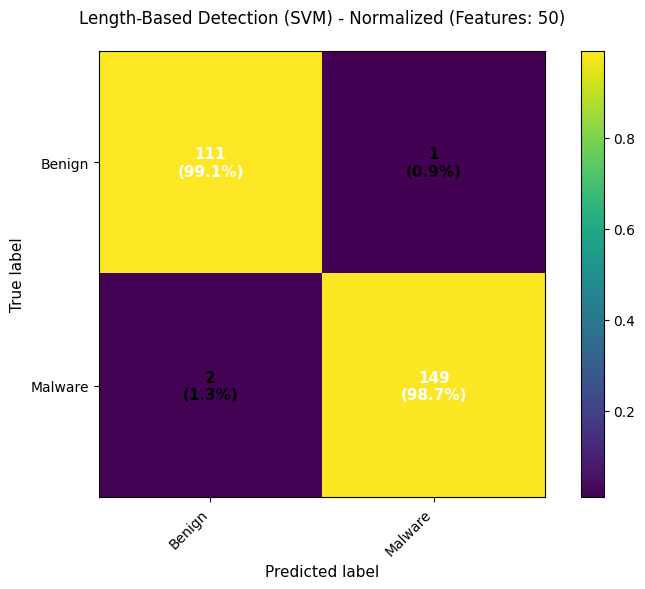


2. Creating raw counts confusion matrix...
Confusion matrix, without normalization
[[111.   1.]
 [  2. 149.]]
   Saved: /content/drive/MyDrive/COLA_Models_Hybrid_Top50/confusion_matrix_raw_svm.png


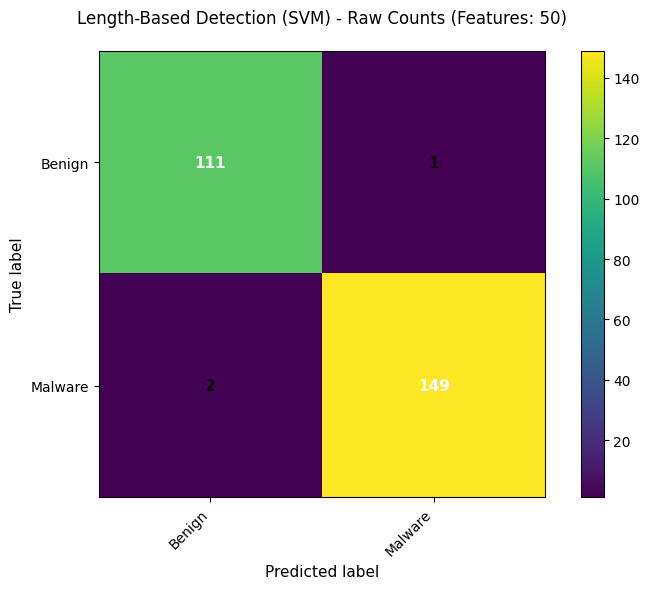


Confusion matrix plots saved successfully
Location: /content/drive/MyDrive/COLA_Models_Hybrid_Top50


In [ ]:
"""
================================================================================
CONFUSION MATRIX PLOTS - SAVE TO FILES
================================================================================
Saves confusion matrix visualizations from training results.
Creates both normalized and raw count versions.
================================================================================
"""
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import os

# Configuration
SAVE_DIR = '/content/drive/MyDrive/COLA_Models_Hybrid_Top50'
SAVE_PLOTS = True  # Set to False to skip saving

if 'training_results' in globals() and SAVE_PLOTS:
    print("Generating and saving confusion matrix plots...")
    print("=" * 60)

    results = globals()['training_results']
    best_model = results['best_model']
    model_results = results['results'][best_model]

    # Get predictions
    y_true = model_results['true_labels']
    y_pred = model_results['predictions']
    feature_count = len(results['selected_names'])

    print(f"Model: {best_model.upper()}")
    print(f"Features: {feature_count}")

    # Create save directory
    os.makedirs(SAVE_DIR, exist_ok=True)

    # Plot 1: Normalized confusion matrix
    print("\n1. Creating normalized confusion matrix...")
    ax1 = plot_confusion_matrix(
        y_true=y_true,
        y_pred=y_pred,
        classes=["Benign", "Malware"],
        normalize="true",
        feature_count=feature_count,
        title=f"Length-Based Detection ({best_model.upper()}) - Normalized"
    )

    filename1 = os.path.join(SAVE_DIR, f"confusion_matrix_normalized_{best_model}.png")
    plt.savefig(filename1, dpi=300, bbox_inches='tight')
    print(f"   Saved: {filename1}")
    plt.show()

    # Plot 2: Raw counts confusion matrix
    print("\n2. Creating raw counts confusion matrix...")
    cm = confusion_matrix(y_true, y_pred)
    ax2 = plot_confusion_matrix(
        cm=cm,
        classes=["Benign", "Malware"],
        normalize=False,
        feature_count=feature_count,
        title=f"Length-Based Detection ({best_model.upper()}) - Raw Counts"
    )

    filename2 = os.path.join(SAVE_DIR, f"confusion_matrix_raw_{best_model}.png")
    plt.savefig(filename2, dpi=300, bbox_inches='tight')
    print(f"   Saved: {filename2}")
    plt.show()

    print("\n" + "=" * 60)
    print("Confusion matrix plots saved successfully")
    print(f"Location: {SAVE_DIR}")

elif not SAVE_PLOTS:
    print("Plot saving disabled (SAVE_PLOTS = False)")
else:
    print("training_results not found - please run the training pipeline first")

Block 1: Load Data and Metadata

In [ ]:
"""
================================================================================
HEATMAP VISUALIZATION - DATA LOADING
================================================================================
Detects and loads feature matrix, feature names, selected indices, and sample
splits from available variables in the notebook environment.
================================================================================
"""
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import PowerNorm, LogNorm
import matplotlib.colors as mcolors

print("FEATURE HEATMAP VISUALIZATION FOR LENGTH-BASED BEHAVIORAL SIGNATURES")
print("="*60)

# Detect available data sources
print("Step 1: Detecting data sources...")

M_plot = None
source_name = None

if 'M2_0' in globals():
    M_plot = globals()['M2_0']
    source_name = 'M2_0'
    print(f"Using M2_0 (shape: {M_plot.shape})")
elif 'M2' in globals():
    M_plot = globals()['M2']
    source_name = 'M2'
    print(f"Using M2 (shape: {M_plot.shape})")
elif 'reduced_df_int' in globals():
    df = globals()['reduced_df_int']
    exclude_cols = ['label', 'sample_type', 'sample_id', 'class']
    feature_cols = [col for col in df.columns if col not in exclude_cols]
    M_plot = df[feature_cols].values
    source_name = 'reduced_df_int'
    print(f"Using reduced_df_int features (shape: {M_plot.shape})")
elif 'reduced_df' in globals():
    df = globals()['reduced_df']
    exclude_cols = ['label', 'sample_type', 'sample_id', 'class']
    feature_cols = [col for col in df.columns if col not in exclude_cols]
    M_plot = df[feature_cols].values
    source_name = 'reduced_df'
    print(f"Using reduced_df features (shape: {M_plot.shape})")
else:
    print("No suitable data matrix found!")
    available = [var for var in globals().keys() if any(x in var for x in ['M2', 'reduced', 'matrix'])]
    print(f"Available variables: {available}")
    raise NameError("Please run your feature extraction code first")

# Get feature names
print("\nStep 2: Getting feature names...")

names_all = None
if 'usedSysCalls_0' in globals():
    names_all = globals()['usedSysCalls_0']
    print(f"Using usedSysCalls_0 ({len(names_all)} names)")
elif 'usedSysCalls' in globals():
    names_all = globals()['usedSysCalls']
    print(f"Using usedSysCalls ({len(names_all)} names)")
elif source_name in ['reduced_df_int', 'reduced_df']:
    names_all = feature_cols
    print(f"Using feature column names ({len(names_all)} names)")
else:
    names_all = [f"Feature_{i}" for i in range(M_plot.shape[1])]
    print(f"Using generic feature names ({len(names_all)} names)")

# Get selected feature indices
print("\nStep 3: Determining feature selection...")

sel_idx = None

if 'training_results' in globals() and 'selected_indices' in globals()['training_results']:
    sel_idx = np.asarray(globals()['training_results']['selected_indices'], dtype=int)
    print(f"Using training_results selected indices ({len(sel_idx)} features)")
elif 'selected_feature_indices' in globals() and len(globals()['selected_feature_indices']) > 0:
    sel_idx = np.asarray(globals()['selected_feature_indices'], dtype=int)
    print(f"Using selected_feature_indices ({len(sel_idx)} features)")
elif source_name in ['reduced_df_int', 'reduced_df']:
    sel_idx = np.arange(M_plot.shape[1], dtype=int)
    print(f"Using all features from reduced DataFrame ({len(sel_idx)} features)")
else:
    max_features_to_show = min(100, M_plot.shape[1])
    sel_idx = np.arange(max_features_to_show, dtype=int)
    print(f"Showing first {max_features_to_show} features (no selection info found)")

# Validate indices
sel_idx = sel_idx[(sel_idx >= 0) & (sel_idx < M_plot.shape[1])]
if sel_idx.size == 0:
    raise ValueError("No valid selected features to plot")

print(f"Final feature selection: {len(sel_idx)} features")

# Get sample splits
print("\nStep 4: Determining sample splits...")

ben = None
mal = None

if 'BENIGN' in globals() and 'MALICIOUS' in globals():
    ben = int(globals()['BENIGN'])
    mal = int(globals()['MALICIOUS'])
    print(f"Using BENIGN/MALICIOUS counts: {ben} benign, {mal} malware")
elif source_name in ['reduced_df_int', 'reduced_df']:
    df = globals()[source_name]
    if 'label' in df.columns:
        ben = int((df['label'] == 0).sum())
        mal = int((df['label'] == 1).sum())
    elif 'class' in df.columns:
        ben = int((df['class'] == 0).sum())
        mal = int((df['class'] == 1).sum())
    print(f"Counted from DataFrame: {ben} benign, {mal} malware")
else:
    ben = M_plot.shape[0] // 2
    mal = M_plot.shape[0] - ben
    print(f"Using half-split assumption: {ben} benign, {mal} malware")

# Validate counts
ben = max(0, min(ben, M_plot.shape[0]))
mal = max(0, min(mal, M_plot.shape[0] - ben))

if ben + mal != M_plot.shape[0]:
    mal = M_plot.shape[0] - ben
    print(f"Adjusted counts to match matrix size")

print(f"Final split: {ben} benign, {mal} malware")

print("\nData loading complete")

FEATURE HEATMAP VISUALIZATION FOR LENGTH-BASED BEHAVIORAL SIGNATURES
Step 1: Detecting data sources...
Using M2_0 (shape: (1312, 401))

Step 2: Getting feature names...
Using usedSysCalls_0 (401 names)

Step 3: Determining feature selection...
Using training_results selected indices (50 features)
Final feature selection: 50 features

Step 4: Determining sample splits...
Using BENIGN/MALICIOUS counts: 559 benign, 753 malware
Final split: 559 benign, 753 malware

Data loading complete


Block 2: Prepare Visualization Data

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import PowerNorm, LogNorm
import matplotlib.colors as mcolors

print("Preparing data for visualization...")

# Calculate proportions
total = max(1, ben + mal)
h_b = ben / total
h_m = mal / total

# Prepare feature labels (limit for readability)
# The `feature_name_labels` variable (containing names) is still useful for context
# but will not be used for y-axis ticks in the heatmap itself.
feature_name_labels = [names_all[i] for i in sel_idx] # Keep original names

# Retrieve selected_ids if available from training_results
selected_ids_from_results = None
if 'training_results' in globals() and 'selected_ids' in globals()['training_results']:
    selected_ids_from_results = globals()['training_results']['selected_ids']

# Determine the labels for the y-axis (syscall IDs)
labels_for_y_axis_raw = []
if selected_ids_from_results is not None: # Check the retrieved variable
    labels_for_y_axis_raw = [str(id_val) for id_val in selected_ids_from_results]
elif 'usedSysCalls_nm_0' in globals() and sel_idx is not None:
    all_ids_str = globals()['usedSysCalls_nm_0']
    labels_for_y_axis_raw = [all_ids_str[i] for i in sel_idx]
elif sel_idx is not None:
    labels_for_y_axis_raw = [f"ID_{i}" for i in sel_idx]
else:
    labels_for_y_axis_raw = [f"ID_{i}" for i in range(M_plot.shape[1])]


max_labels = 50

if len(labels_for_y_axis_raw) > max_labels:
    label_idx_for_display = np.linspace(0, len(labels_for_y_axis_raw)-1, num=max_labels, dtype=int)
    display_labels = [labels_for_y_axis_raw[i] for i in label_idx_for_display]
    print(f"Showing {max_labels} feature IDs (from {len(labels_for_y_axis_raw)} total) on y-axis")
else:
    label_idx_for_display = np.arange(len(labels_for_y_axis_raw))
    display_labels = labels_for_y_axis_raw
    print(f"Showing all {len(labels_for_y_axis_raw)} feature IDs on y-axis")


# Prepare data slices (transpose: features on Y-axis, samples on X-axis)
ben_slice = M_plot[:ben, :][:, sel_idx].T if ben > 0 else None
mal_slice = M_plot[-mal:, :][:, sel_idx].T if mal > 0 else None

# Show feature characteristics
if M_plot.size > 0:
    print(f"\nLength-based feature characteristics:")
    print(f"  Value range: [{M_plot.min():.4f}, {M_plot.max():.4f}]")
    print(f"  Sparsity: {1 - np.count_nonzero(M_plot)/M_plot.size:.4f}")
    if np.count_nonzero(M_plot) > 0:
        print(f"  Mean non-zero: {M_plot[M_plot > 0].mean():.4f}")

# Configure color intensity enhancement
data_min = M_plot.min()
data_max = M_plot.max()

print(f"\nConfiguring color intensity...")
print(f"Data range: [{data_min:.4f}, {data_max:.4f}]")

# Choose intensity enhancement: "power", "log", "percentile", "custom"
intensity_method = "power"

if intensity_method == "power":
    norm = PowerNorm(gamma=0.5)
    print("Using power normalization (gamma=0.5)")
elif intensity_method == "log" and data_min > 0:
    norm = LogNorm(vmin=max(data_min, 0.001), vmax=data_max)
    print("Using log normalization")
elif intensity_method == "percentile":
    p_low, p_high = np.percentile(M_plot[M_plot > 0], [5, 95]) if np.count_nonzero(M_plot) > 0 else (data_min, data_max)
    norm = mcolors.Normalize(vmin=p_low, vmax=p_high)
    print(f"Using percentile clipping: [{p_low:.4f}, {p_high:.4f}]")
else:
    vmin = np.percentile(M_plot[M_plot > 0], 1) if np.count_nonzero(M_plot) > 0 else data_min
    vmax = np.percentile(M_plot, 98)
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    print(f"Using custom range: [{vmin:.4f}, {vmax:.4f}]")

# Colormap selection
cmap_benign = 'Blues'
cmap_malware = 'inferno'  # Very intense: black-red-yellow

print(f"Colormaps: Benign={cmap_benign}, Malware={cmap_malware}")
print("\nData preparation complete")

Preparing data for visualization...
Showing all 50 feature IDs on y-axis

Length-based feature characteristics:
  Value range: [0.0000, 1089.2275]
  Sparsity: 0.8552
  Mean non-zero: 3.8569

Configuring color intensity...
Data range: [0.0000, 1089.2275]
Using power normalization (gamma=0.5)
Colormaps: Benign=Blues, Malware=inferno

Data preparation complete


Block 3: Create and Display Visualization adn  Save Visualization

Creating visualization...
Visualization created

✅ Plot saved as: /content/drive/MyDrive/COLA_Models_Hybrid_Top50/length_based_heatmap_M2_0_50features.png

EXPORTING HEATMAP DATA TO CSV
✅ Benign heatmap data: /content/drive/MyDrive/COLA_Models_Hybrid_Top50/heatmap_benign_M2_0_50features.csv
   Shape: (50, 559) (features × samples)
✅ Malware heatmap data: /content/drive/MyDrive/COLA_Models_Hybrid_Top50/heatmap_malware_M2_0_50features.csv
   Shape: (50, 753) (features × samples)
✅ Combined heatmap data: /content/drive/MyDrive/COLA_Models_Hybrid_Top50/heatmap_combined_M2_0_50features.csv
   Shape: (51, 1312) (features+1 × samples)
   Note: First row = Class_Label (0=Benign, 1=Malware)
✅ Statistics summary: /content/drive/MyDrive/COLA_Models_Hybrid_Top50/heatmap_statistics_M2_0_50features.csv

📁 All CSV files saved to: /content/drive/MyDrive/COLA_Models_Hybrid_Top50

Interpretation:
  - Brighter colors = Higher behavioral complexity scores
  - Each row = One syscall feature (behavioral sig

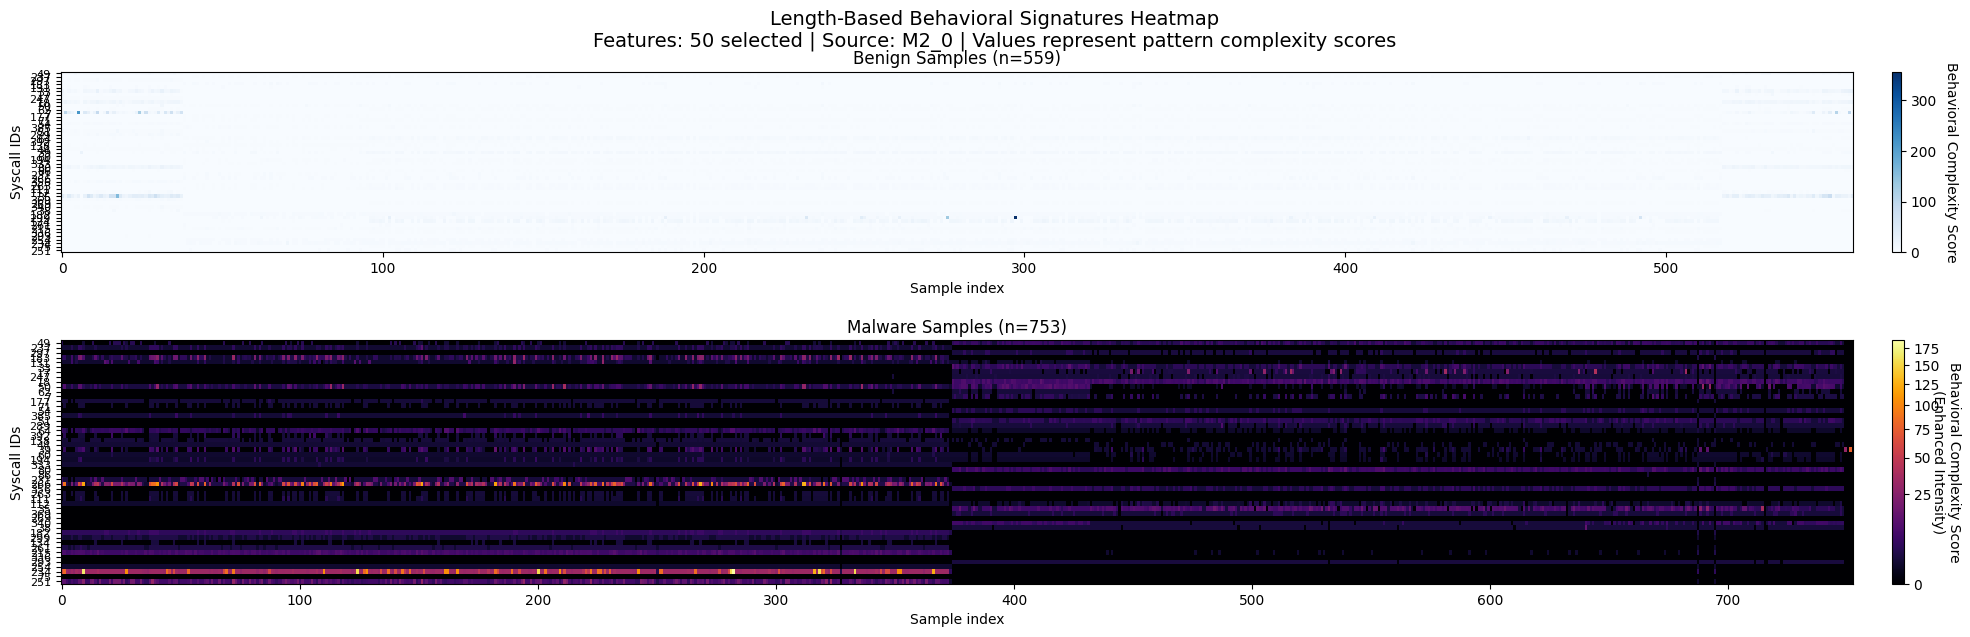


✅ Visualization and data export complete!


In [ ]:
import os
import pandas as pd

# Configuration
SAVE_PLOT = True  # Set to False to skip saving
SAVE_CSV = True   # Set to False to skip CSV export
SAVE_DIR = '/content/drive/MyDrive/COLA_Models_Hybrid_Top50'

print("Creating visualization...")

fig = plt.figure(figsize=(20, 6 + 0.004 * len(sel_idx)))

# Overall title
fig.suptitle(f'Length-Based Behavioral Signatures Heatmap\n'
            f'Features: {len(sel_idx)} selected | Source: {source_name} | '
            f'Values represent pattern complexity scores', fontsize=14, y=1.02) # Increased y for title position

gs = gridspec.GridSpec(2, 1, height_ratios=[h_b if ben > 0 else 0.0001,
                                            h_m if mal > 0 else 0.0001])

# Benign subplot
ax0 = fig.add_subplot(gs[0])
ax0.set_title(f"Benign Samples (n={ben})", fontsize=12)
if ben_slice is not None and ben > 0:
    im0 = ax0.imshow(ben_slice, aspect='auto', cmap=cmap_benign,
                     interpolation='nearest', origin='lower')
    cbar0 = plt.colorbar(im0, ax=ax0, fraction=0.046, pad=0.02)
    cbar0.set_label('Behavioral Complexity Score', rotation=270, labelpad=15)
    if len(label_idx_for_display) > 0:
        ax0.set_yticks(label_idx_for_display)
        ax0.set_yticklabels(display_labels, fontsize=8) # Changed to display_labels
    ax0.set_xlabel("Sample index")
    ax0.set_ylabel("Syscall IDs") # Changed label text
else:
    ax0.text(0.5, 0.5, "No benign samples", ha='center', va='center',
             transform=ax0.transAxes, fontsize=12)
    ax0.set_xlim(0, 1)
    ax0.set_ylim(0, 1)

# Malware subplot
ax1 = fig.add_subplot(gs[1])
ax1.set_title(f"Malware Samples (n={mal})", fontsize=12)
if mal_slice is not None and mal > 0:
    im1 = ax1.imshow(mal_slice, aspect='auto', cmap=cmap_malware,
                     interpolation='nearest', origin='lower', norm=norm)
    cbar1 = plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.02)
    cbar1.set_label('Behavioral Complexity Score\n(Enhanced Intensity)',
                    rotation=270, labelpad=15)
    if len(label_idx_for_display) > 0:
        ax1.set_yticks(label_idx_for_display)
        ax1.set_yticklabels(display_labels, fontsize=8) # Changed to display_labels
    ax1.set_xlabel("Sample index")
    ax1.set_ylabel("Syscall IDs") # Changed label text
else:
    ax1.text(0.5, 0.5, "No malware samples", ha='center', va='center',
             transform=ax1.transAxes, fontsize=12)
    ax1.set_xlim(0, 1)
    ax1.set_ylim(0, 1)

plt.tight_layout()
plt.subplots_adjust(top=0.92) # Adjusted top for title

print("Visualization created")

# ============================================================================
# SAVE PLOT
# ============================================================================
if SAVE_PLOT:
    os.makedirs(SAVE_DIR, exist_ok=True)
    plot_filename = os.path.join(SAVE_DIR, f"length_based_heatmap_{source_name}_{len(sel_idx)}features.png")
    plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
    print(f"\n✅ Plot saved as: {plot_filename}")

# ============================================================================
# EXPORT HEATMAP DATA TO CSV
# ============================================================================
if SAVE_CSV:
    print("\n" + "="*80)
    print("EXPORTING HEATMAP DATA TO CSV")
    print("="*80)
    os.makedirs(SAVE_DIR, exist_ok=True)

    # Prepare feature names for row labels
    if 'display_labels' in locals() and len(display_labels) == len(sel_idx):
        feature_names_for_csv = display_labels # Use IDs for CSV labels too
    else:
        feature_names_for_csv = [f"Feature_{i}" for i in range(len(sel_idx))]

    # 1. Export Benign heatmap data
    if ben_slice is not None and ben > 0:
        benign_df = pd.DataFrame(
            ben_slice,
            index=feature_names_for_csv,
            columns=[f"Benign_Sample_{i}" for i in range(ben)]
        )
        benign_csv = os.path.join(SAVE_DIR, f"heatmap_benign_{source_name}_{len(sel_idx)}features.csv")
        benign_df.to_csv(benign_csv)
        print(f"✅ Benign heatmap data: {benign_csv}")
        print(f"   Shape: {benign_df.shape} (features × samples)")

    # 2. Export Malware heatmap data
    if mal_slice is not None and mal > 0:
        malware_df = pd.DataFrame(
            mal_slice,
            index=feature_names_for_csv,
            columns=[f"Malware_Sample_{i}" for i in range(mal)]
        )
        malware_csv = os.path.join(SAVE_DIR, f"heatmap_malware_{source_name}_{len(sel_idx)}features.csv")
        malware_df.to_csv(malware_csv)
        print(f"✅ Malware heatmap data: {malware_csv}")
        print(f"   Shape: {malware_df.shape} (features × samples)")

    # 3. Export Combined heatmap data with labels
    if ben_slice is not None and mal_slice is not None and ben > 0 and mal > 0:
        # Concatenate horizontally (features × all samples)
        combined_data = np.hstack([ben_slice, mal_slice])

        # Create column names
        benign_cols = [f"Benign_{i}" for i in range(ben)]
        malware_cols = [f"Malware_{i}" for i in range(mal)]
        all_cols = benign_cols + malware_cols

        # Create DataFrame
        combined_df = pd.DataFrame(
            combined_data,
            index=feature_names_for_csv,
            columns=all_cols
        )

        # Add metadata row at top with class labels
        label_row = pd.Series(
            [0] * ben + [1] * mal,
            index=all_cols,
            name='Class_Label'
        )

        # Prepend label row
        combined_df = pd.concat([pd.DataFrame([label_row]), combined_df])

        combined_csv = os.path.join(SAVE_DIR, f"heatmap_combined_{source_name}_{len(sel_idx)}features.csv")
        combined_df.to_csv(combined_csv)
        print(f"✅ Combined heatmap data: {combined_csv}")
        print(f"   Shape: {combined_df.shape} (features+1 × samples)")
        print(f"   Note: First row = Class_Label (0=Benign, 1=Malware)")

    # 4. Export summary statistics
    stats_data = []

    if ben_slice is not None and ben > 0:
        stats_data.append({
            'Class': 'Benign',
            'Samples': ben,
            'Features': len(sel_idx),
            'Min_Value': ben_slice.min(),
            'Max_Value': ben_slice.max(),
            'Mean_Value': ben_slice.mean(),
            'Median_Value': np.median(ben_slice),
            'Std_Value': ben_slice.std(),
            'Non_Zero_Count': np.count_nonzero(ben_slice),
            'Sparsity': 1 - np.count_nonzero(ben_slice) / ben_slice.size
        })

    if mal_slice is not None and mal > 0:
        stats_data.append({
            'Class': 'Malware',
            'Samples': mal,
            'Features': len(sel_idx),
            'Min_Value': mal_slice.min(),
            'Max_Value': mal_slice.max(),
            'Mean_Value': mal_slice.mean(),
            'Median_Value': np.median(mal_slice),
            'Std_Value': mal_slice.std(),
            'Non_Zero_Count': np.count_nonzero(mal_slice),
            'Sparsity': 1 - np.count_nonzero(mal_slice) / mal_slice.size
        })

    if stats_data:
        stats_df = pd.DataFrame(stats_data)
        stats_csv = os.path.join(SAVE_DIR, f"heatmap_statistics_{source_name}_{len(sel_idx)}features.csv")
        stats_df.to_csv(stats_csv, index=False)
        print(f"✅ Statistics summary: {stats_csv}")

    print(f"\n📁 All CSV files saved to: {SAVE_DIR}")
    print("="*80)

# ============================================================================
# DISPLAY INTERPRETATION
# ============================================================================
print(f"\nInterpretation:")
print(f"  - Brighter colors = Higher behavioral complexity scores")
print(f"  - Each row = One syscall feature (behavioral signature)")
print(f"  - Each column = One sample")
print(f"  - Values are time-invariant pattern sophistication measures")

# Show plot
plt.show()

print("\n✅ Visualization and data export complete!")

📊 Reading from CSV: /content/drive/MyDrive/COLA_Models_Hybrid_Top50/heatmap_statistics_M2_0_50features.csv
✅ Data loaded from: CSV
   Benign:  559 samples, Mean=1.446
   Malware: 753 samples, Mean=2.109
   Mean Separation: 45.8%


/tmp/ipython-input-119519621.py:293: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipython-input-119519621.py:298: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(plot_file, dpi=300, bbox_inches='tight')



✅ Visualization saved: /content/drive/MyDrive/COLA_Models_Hybrid_Top50/class_separation_visualization.png
📊 Data source: CSV
   Mean Separation: 45.8% (✅ Good)


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


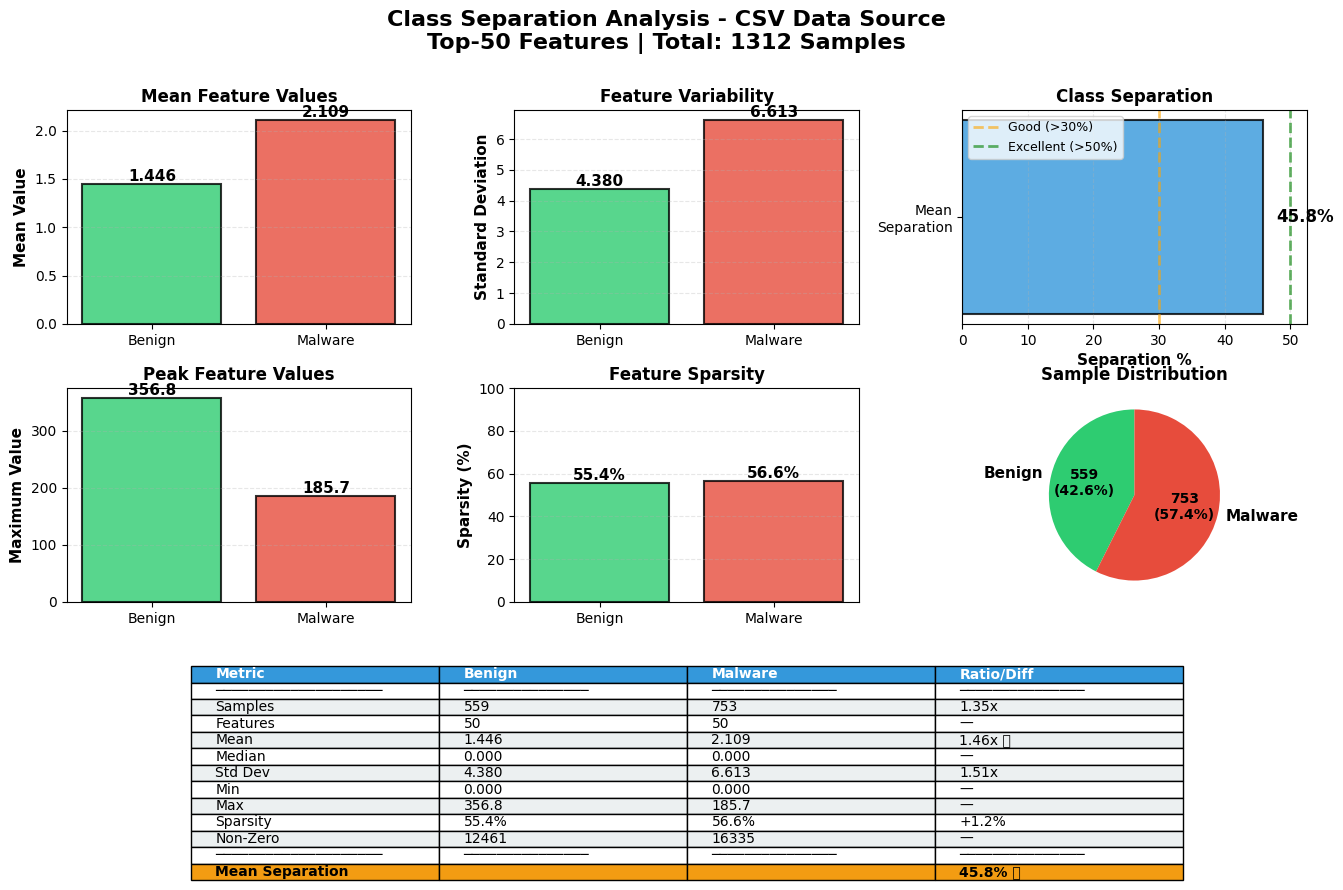

In [ ]:
"""
================================================================================
CLASS SEPARATION VISUALIZATION - FLEXIBLE DATA SOURCE
================================================================================
Reads data from CSV if available, otherwise from training_results variable.
================================================================================
"""
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

# ============================================================================
# Configuration
# ============================================================================
SAVE_DIR = '/content/drive/MyDrive/COLA_Models_Hybrid_Top50'

# ============================================================================
# Try to get data from multiple sources
# ============================================================================
data_source = None
benign_stats = None
malware_stats = None

# SOURCE 1: Try CSV file
stats_files = []
if os.path.exists(SAVE_DIR):
    stats_files = [f for f in os.listdir(SAVE_DIR) if f.startswith('heatmap_statistics_') and f.endswith('.csv')]

if stats_files:
    stats_file = os.path.join(SAVE_DIR, stats_files[-1])
    print(f"📊 Reading from CSV: {stats_file}")

    df = pd.read_csv(stats_file)
    benign_row = df[df['Class'] == 'Benign'].iloc[0]
    malware_row = df[df['Class'] == 'Malware'].iloc[0]

    benign_stats = {
        'samples': int(benign_row['Samples']),
        'features': int(benign_row['Features']),
        'mean': float(benign_row['Mean_Value']),
        'median': float(benign_row['Median_Value']),
        'std': float(benign_row['Std_Value']),
        'min': float(benign_row['Min_Value']),
        'max': float(benign_row['Max_Value']),
        'sparsity': float(benign_row['Sparsity']) * 100,
        'non_zero': int(benign_row['Non_Zero_Count'])
    }

    malware_stats = {
        'samples': int(malware_row['Samples']),
        'features': int(malware_row['Features']),
        'mean': float(malware_row['Mean_Value']),
        'median': float(malware_row['Median_Value']),
        'std': float(malware_row['Std_Value']),
        'min': float(malware_row['Min_Value']),
        'max': float(malware_row['Max_Value']),
        'sparsity': float(malware_row['Sparsity']) * 100,
        'non_zero': int(malware_row['Non_Zero_Count'])
    }

    data_source = "CSV"

# SOURCE 2: Try training_results variable
elif 'training_results' in globals():
    print(f"📊 Reading from training_results variable")

    results = globals()['training_results']

    # Get the selected features data
    selected_indices = results.get('selected_indices', [])
    X_selected = globals().get('M2_0', None)

    if X_selected is not None and len(selected_indices) > 0:
        # Apply feature selection
        X_selected = X_selected[:, selected_indices]

        BENIGN = globals().get('BENIGN', 559)
        MALICIOUS = globals().get('MALICIOUS', 752)

        benign_data = X_selected[:BENIGN]
        malware_data = X_selected[BENIGN:]

        benign_stats = {
            'samples': BENIGN,
            'features': len(selected_indices),
            'mean': float(benign_data.mean()),
            'median': float(np.median(benign_data)),
            'std': float(benign_data.std()),
            'min': float(benign_data.min()),
            'max': float(benign_data.max()),
            'sparsity': (1 - np.count_nonzero(benign_data) / benign_data.size) * 100,
            'non_zero': int(np.count_nonzero(benign_data))
        }

        malware_stats = {
            'samples': MALICIOUS,
            'features': len(selected_indices),
            'mean': float(malware_data.mean()),
            'median': float(np.median(malware_data)),
            'std': float(malware_data.std()),
            'min': float(malware_data.min()),
            'max': float(malware_data.max()),
            'sparsity': (1 - np.count_nonzero(malware_data) / malware_data.size) * 100,
            'non_zero': int(np.count_nonzero(malware_data))
        }

        data_source = "training_results"

# SOURCE 3: Manual input (your current values)
else:
    print(f"📊 Using manually entered values")

    benign_stats = {
        'samples': 559,
        'features': 50,
        'mean': 1.446,
        'median': 0.0,
        'std': 4.38,
        'min': 0.0,
        'max': 356.79,
        'sparsity': 55.4,
        'non_zero': 12461
    }

    malware_stats = {
        'samples': 753,
        'features': 50,
        'mean': 2.109,
        'median': 0.0,
        'std': 6.61,
        'min': 0.0,
        'max': 185.73,
        'sparsity': 56.6,
        'non_zero': 16335
    }

    data_source = "Manual"

# ============================================================================
# Validate we have data
# ============================================================================
if benign_stats is None or malware_stats is None:
    print("❌ ERROR: Could not load statistics from any source!")
    print("   Please run the training pipeline or heatmap generation first.")
else:
    print(f"✅ Data loaded from: {data_source}")
    print(f"   Benign:  {benign_stats['samples']} samples, Mean={benign_stats['mean']:.3f}")
    print(f"   Malware: {malware_stats['samples']} samples, Mean={malware_stats['mean']:.3f}")

    # Calculate derived metrics
    mean_separation = abs(malware_stats['mean'] - benign_stats['mean']) / benign_stats['mean'] * 100 if benign_stats['mean'] > 0 else 0
    mean_ratio = malware_stats['mean'] / benign_stats['mean'] if benign_stats['mean'] > 0 else 0
    std_ratio = malware_stats['std'] / benign_stats['std'] if benign_stats['std'] > 0 else 0

    print(f"   Mean Separation: {mean_separation:.1f}%")

    # ========================================================================
    # Create visualization (same as before)
    # ========================================================================

    fig = plt.figure(figsize=(16, 10))
    fig.suptitle(f'Class Separation Analysis - {data_source} Data Source\n'
                 f'Top-{benign_stats["features"]} Features | Total: {benign_stats["samples"] + malware_stats["samples"]} Samples',
                 fontsize=16, fontweight='bold')

    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

    # --- Plot 1: Mean Values ---
    ax1 = fig.add_subplot(gs[0, 0])
    x = ['Benign', 'Malware']
    means = [benign_stats['mean'], malware_stats['mean']]
    colors = ['#2ecc71', '#e74c3c']

    bars = ax1.bar(x, means, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
    ax1.set_ylabel('Mean Value', fontweight='bold', fontsize=11)
    ax1.set_title('Mean Feature Values', fontweight='bold', fontsize=12)
    ax1.grid(axis='y', alpha=0.3, linestyle='--')

    for bar, val in zip(bars, means):
        ax1.text(bar.get_x() + bar.get_width()/2., val,
                f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

    # --- Plot 2: Standard Deviation ---
    ax2 = fig.add_subplot(gs[0, 1])
    stds = [benign_stats['std'], malware_stats['std']]

    bars = ax2.bar(x, stds, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
    ax2.set_ylabel('Standard Deviation', fontweight='bold', fontsize=11)
    ax2.set_title('Feature Variability', fontweight='bold', fontsize=12)
    ax2.grid(axis='y', alpha=0.3, linestyle='--')

    for bar, val in zip(bars, stds):
        ax2.text(bar.get_x() + bar.get_width()/2., val,
                f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

    # --- Plot 3: Separation Metric ---
    ax3 = fig.add_subplot(gs[0, 2])
    ax3.barh(['Mean\nSeparation'], [mean_separation], color='#3498db', alpha=0.8, edgecolor='black', linewidth=1.5)
    ax3.set_xlabel('Separation %', fontweight='bold', fontsize=11)
    ax3.set_title('Class Separation', fontweight='bold', fontsize=12)
    ax3.axvline(x=30, color='orange', linestyle='--', alpha=0.6, linewidth=2, label='Good (>30%)')
    ax3.axvline(x=50, color='green', linestyle='--', alpha=0.6, linewidth=2, label='Excellent (>50%)')
    ax3.legend(fontsize=9)
    ax3.grid(axis='x', alpha=0.3, linestyle='--')
    ax3.text(mean_separation + 2, 0, f'{mean_separation:.1f}%',
             va='center', fontsize=12, fontweight='bold')

    # --- Plot 4: Max Values ---
    ax4 = fig.add_subplot(gs[1, 0])
    maxs = [benign_stats['max'], malware_stats['max']]

    bars = ax4.bar(x, maxs, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
    ax4.set_ylabel('Maximum Value', fontweight='bold', fontsize=11)
    ax4.set_title('Peak Feature Values', fontweight='bold', fontsize=12)
    ax4.grid(axis='y', alpha=0.3, linestyle='--')

    for bar, val in zip(bars, maxs):
        ax4.text(bar.get_x() + bar.get_width()/2., val,
                f'{val:.1f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

    # --- Plot 5: Sparsity ---
    ax5 = fig.add_subplot(gs[1, 1])
    sparsities = [benign_stats['sparsity'], malware_stats['sparsity']]

    bars = ax5.bar(x, sparsities, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
    ax5.set_ylabel('Sparsity (%)', fontweight='bold', fontsize=11)
    ax5.set_title('Feature Sparsity', fontweight='bold', fontsize=12)
    ax5.set_ylim([0, 100])
    ax5.grid(axis='y', alpha=0.3, linestyle='--')

    for bar, val in zip(bars, sparsities):
        ax5.text(bar.get_x() + bar.get_width()/2., val,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

    # --- Plot 6: Sample Distribution ---
    ax6 = fig.add_subplot(gs[1, 2])
    samples = [benign_stats['samples'], malware_stats['samples']]

    wedges, texts, autotexts = ax6.pie(samples, labels=x, autopct='%1.1f%%',
                                         colors=colors, startangle=90,
                                         textprops={'fontsize': 11, 'fontweight': 'bold'})
    ax6.set_title('Sample Distribution', fontweight='bold', fontsize=12)

    for autotext, count in zip(autotexts, samples):
        autotext.set_text(f'{count}\n({autotext.get_text()})')
        autotext.set_fontsize(10)

    # --- Plot 7: Summary Table ---
    ax7 = fig.add_subplot(gs[2, :])
    ax7.axis('off')

    table_data = [
        ['Metric', 'Benign', 'Malware', 'Ratio/Diff'],
        ['─'*20, '─'*15, '─'*15, '─'*15],
        ['Samples', f"{benign_stats['samples']}", f"{malware_stats['samples']}",
         f"{malware_stats['samples']/benign_stats['samples']:.2f}x"],
        ['Features', f"{benign_stats['features']}", f"{malware_stats['features']}", '—'],
        ['Mean', f"{benign_stats['mean']:.3f}", f"{malware_stats['mean']:.3f}",
         f"{mean_ratio:.2f}x {'✅' if mean_ratio > 1 else '⚠️'}"],
        ['Median', f"{benign_stats['median']:.3f}", f"{malware_stats['median']:.3f}", '—'],
        ['Std Dev', f"{benign_stats['std']:.3f}", f"{malware_stats['std']:.3f}",
         f"{std_ratio:.2f}x"],
        ['Min', f"{benign_stats['min']:.3f}", f"{malware_stats['min']:.3f}", '—'],
        ['Max', f"{benign_stats['max']:.1f}", f"{malware_stats['max']:.1f}", '—'],
        ['Sparsity', f"{benign_stats['sparsity']:.1f}%", f"{malware_stats['sparsity']:.1f}%",
         f"{malware_stats['sparsity'] - benign_stats['sparsity']:+.1f}%"],
        ['Non-Zero', f"{benign_stats['non_zero']}", f"{malware_stats['non_zero']}", '—'],
        ['─'*20, '─'*15, '─'*15, '─'*15],
        ['Mean Separation', '', '', f"{mean_separation:.1f}% {'✅' if mean_separation > 40 else '⚠️'}"],
    ]

    table = ax7.table(cellText=table_data, cellLoc='left',
                      loc='center', bbox=[0.1, 0.0, 0.8, 1.0])

    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2)

    for i in range(4):
        table[(0, i)].set_facecolor('#3498db')
        table[(0, i)].set_text_props(weight='bold', color='white')

    for i in range(2, len(table_data)):
        for j in range(4):
            if i % 2 == 0:
                table[(i, j)].set_facecolor('#ecf0f1')

    for j in range(4):
        table[(len(table_data)-1, j)].set_facecolor('#f39c12')
        table[(len(table_data)-1, j)].set_text_props(weight='bold')

    plt.tight_layout()

    # Save
    os.makedirs(SAVE_DIR, exist_ok=True)
    plot_file = os.path.join(SAVE_DIR, 'class_separation_visualization.png')
    plt.savefig(plot_file, dpi=300, bbox_inches='tight')

    print("\n" + "="*80)
    print(f"✅ Visualization saved: {plot_file}")
    print(f"📊 Data source: {data_source}")
    print(f"   Mean Separation: {mean_separation:.1f}% ({'✅ Excellent' if mean_separation > 50 else '✅ Good' if mean_separation > 30 else '⚠️ Moderate'})")
    print("="*80)

    plt.show()